# pose-image-tool — 참조 이미지의 **자세만** 가져와 새 이미지 만들기

사진 속 인물의 **포즈(관절 구조)** 만 뽑아내서, 인물·의상·배경·화풍은 내가 쓴 글(프롬프트)대로
완전히 새로 그려내는 노트북입니다.

| 항목 | 내용 |
| --- | --- |
| 실행 환경 | Google Colab **무료 T4 GPU** |
| 자세 추출 | OpenPose (`controlnet_aux`) |
| 그림 생성 | **FLUX.2 [klein] 4B** (GGUF Q4 양자화) + **ComfyUI** |
| 첫 실행 소요 시간 | 약 20~30분 (설치 3~5분 + 모델 내려받기 약 11GB) |
| 두 번째부터 | 이미지 한 장당 **30~90초** |
| 비용 | 무료 |

> **이 브랜치(`vFLUX2`)에서 바뀐 것** — 그림을 그리는 모델을 `Stable Diffusion 1.5 + ControlNet` 에서
> **`FLUX.2 [klein] 4B`** 로 교체했습니다. 자세를 뽑아내는 방식(OpenPose)은 그대로입니다.

---

## 이 노트북이 하는 일

```
   ① 참조 사진             ② 스켈레톤(뼈대)            ③ 최종 결과
 ┌───────────────┐      ┌───────────────┐      ┌───────────────┐
 │  팔 든 사람   │ ───▶ │ 검은 배경 위   │ ───▶ │ 갑옷 입은 기사 │
 │   (내 사진)   │      │  색깔 점과 선  │      │ (프롬프트대로) │
 └───────────────┘      └───────────────┘      └───────────────┘
                         OpenPose가 추출          FLUX.2가 생성
                                              ＋ 스켈레톤을 참조 이미지로 제시
```

**자세는 참조 사진에서, 나머지 전부(누가·무엇을 입고·어디서·어떤 화풍)는 프롬프트에서** 옵니다.
참조 사진의 얼굴·피부색·옷은 **결과에 전혀 전달되지 않습니다.** 관절 좌표만 넘어갑니다.

---

## 예전 버전과 무엇이 다른가 — 꼭 읽으세요

| | 이전 (`main` 브랜치, SD 1.5 + ControlNet) | 지금 (`vFLUX2`, FLUX.2 klein) |
| --- | --- | --- |
| 자세를 넘기는 방법 | ControlNet이 **그리는 매 단계마다 강제** | 스켈레톤을 **참조 이미지로 보여 주고 말로 지시** |
| 자세 정확도 | **매우 높음** (거의 그대로) | 높지만 **완벽하지 않음** (가끔 어긋남) |
| 자세 세기 조절 | `POSE_STRENGTH` 숫자 (0.8~1.2) | `POSE_STRICTNESS` 3단계 (지시 문장의 강도) |
| 그림 품질·손가락 | 보통 (손이 자주 뭉개짐) | **훨씬 좋음** |
| 프롬프트 이해력 | 단어 나열 위주, 약 77토큰까지만 | **긴 자연스러운 문장**을 이해함 |
| 한 장 걸리는 시간 | 10~20초 | 30~90초 |
| 첫 준비 시간 | 약 6~9분 | 약 20~30분 (모델 11GB) |

**왜 ControlNet을 쓰지 않나요?**
FLUX.2 klein 전용 OpenPose ControlNet은 (2026년 9월 기준) 아직 공개된 것이 없습니다.
대신 FLUX.2 는 **참조 이미지를 그대로 읽어 들이는 기능**(image reference)을 모델 자체에 갖고 있습니다.
그래서 스켈레톤 그림을 참조 이미지로 넣고 *"이 뼈대와 같은 자세로 그려라"* 라고 지시하는 방식을 씁니다.

정리하면 — **자세가 100% 그대로 옮겨지지는 않습니다. 대신 그림 품질이 크게 올라갑니다.**
자세 정확도가 무엇보다 중요하다면 `main` 브랜치(SD 1.5 + ControlNet)가 여전히 더 낫습니다.

---

## 전체 단계 지도

| STEP | 하는 일 | 걸리는 시간 | 다시 실행해야 할 때 |
| --- | --- | --- | --- |
| **0** | GPU 켜기 | 30초 | 런타임 새로 연결할 때마다 |
| **1** | 도구 설치 (ComfyUI 등) | 3~5분 | 런타임 새로 연결할 때마다 |
| **2** | 라이브러리 불러오기 | 10초 | 런타임 새로 연결할 때마다 |
| **3** | 참조 사진 올리기 | 30초 | 다른 사진을 쓸 때 |
| **4** | 사진 열기 · 크기 계산 | 즉시 | 사진을 바꿀 때 |
| **5** | 자세(스켈레톤) 추출 | 첫 1분 / 이후 3초 | 사진을 바꿀 때 |
| **6** | 모델 내려받기 · 생성 엔진 켜기 | **첫 15~25분** / 이후 1분 | 런타임 새로 연결할 때마다 |
| **7** | 프롬프트·설정 정하기 | 즉시 | **실험할 때마다** |
| **8** | 이미지 생성 | 30~90초 | **실험할 때마다** |
| **9** | 저장 · 비교 · 다운로드 | 5초 | 결과를 남길 때 |
| **10** | 여러 장 한 번에 뽑기 | 장당 30~90초 | 선택 사항 |

> 한 번 다 돌리고 나면, 보통 **STEP 7 → STEP 8 → STEP 9 만 반복**하게 됩니다.
> 앞 단계(설치·모델 로딩)는 그대로 살아 있어서 다시 할 필요가 없습니다.

---

## 노트북을 처음 써 보는 분께

* **셀(cell)** — 이 문서를 이루는 네모 칸 하나하나입니다. 회색 배경에 코드가 적힌 칸이 **코드 셀**,
  지금 읽고 있는 설명 칸이 **텍스트 셀**입니다.
* **실행 방법** — 코드 셀을 클릭한 뒤 **`Shift` + `Enter`**, 또는 셀 왼쪽의 **▶ 버튼**을 누릅니다.
* **끝났는지 확인** — 실행 중이면 왼쪽에 **`[*]`** 또는 회전하는 원, 끝나면 **`[1]`, `[2]`** 처럼
  숫자가 붙습니다. **숫자가 붙을 때까지 기다린 뒤** 다음 셀로 가세요.
* **순서 지키기** — 이 노트북은 **위에서부터 순서대로** 실행하도록 만들어져 있습니다.
  건너뛰면 아래 셀에서 `NameError` 가 납니다.
* **주석 해제** — 코드 앞에 `#` 이 붙은 줄은 "실행되지 않는 메모"입니다.
  쓰고 싶으면 `#` 을 지우면 됩니다. 여러 줄을 한 번에 바꾸려면 드래그 후 **`Ctrl` + `/`**.
* **꼬였을 때** — 상단 메뉴 **런타임 → 세션 다시 시작 및 모두 실행** 으로 처음부터 다시 돌립니다.

문제가 생기면 맨 아래 **문제 해결** 표와 **용어 사전**을 보세요.

---
# STEP 0 — GPU 런타임 켜기

**이 노트북에서 가장 중요한 단계입니다.** GPU 없이 돌리면 이미지 한 장에 10분 이상 걸립니다.

## 0-1. 설정 방법

1. 상단 메뉴 **런타임(Runtime)** 클릭
2. **런타임 유형 변경(Change runtime type)** 클릭
3. **하드웨어 가속기(Hardware accelerator)** 를 **`T4 GPU`** 로 선택
4. **저장(Save)** 클릭 — 런타임이 다시 시작될 수 있습니다. 정상입니다.

> **T4가 무엇인가요?**
> Colab 무료 계정에 배정되는 NVIDIA 그래픽카드입니다. 그래픽카드 메모리(VRAM)가 약 15GB로,
> 이 노트북이 쓰는 FLUX.2(압축본 2.6GB + 텍스트 인코더 8GB)를 돌리기에 넉넉합니다.
> GPU는 같은 계산을 수천 개씩 동시에 처리해서, 그림 생성 같은 작업에서 CPU보다 수십 배 빠릅니다.

## 0-2. 제대로 붙었는지 확인

아래 셀을 실행하세요. `nvidia-smi` 는 **그래픽카드 상태를 보여 주는 프로그램**입니다.
이 셀은 그 프로그램을 찾아 실행하고, **찾지 못하면 무엇을 해야 하는지 한국어로 알려 줍니다.**

> 셀 왼쪽에 `[1]` 처럼 숫자가 붙을 때까지 기다리세요. `[*]` 는 아직 실행 중이라는 뜻입니다.

In [191]:
# [STEP 0-2] GPU가 붙었는지 확인

import shutil
import subprocess

if shutil.which("nvidia-smi") is None:
    # nvidia-smi 프로그램 자체가 없다 = NVIDIA GPU가 붙어 있지 않다
    print("!" * 66)
    print("GPU가 잡히지 않았습니다. (nvidia-smi 프로그램을 찾을 수 없음)")
    print()
    print("확인할 것 두 가지")
    print("  1. 지금 연결된 것이 Colab 런타임이 맞는지")
    print("     -> VS Code 오른쪽 위 커널 선택 칸에 Colab 런타임이 떠 있어야 합니다.")
    print("        내 PC의 파이썬이 잡혀 있으면 이 노트북은 동작하지 않습니다.")
    print("  2. 런타임 유형이 T4 GPU 인지")
    print("     -> [런타임 > 런타임 유형 변경 > T4 GPU] 로 바꾼 뒤")
    print("        이 셀을 다시 실행하세요. (STEP 0-1 참고)")
    print("!" * 66)
else:
    done = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
    print(done.stdout)
    if "Tesla T4" in done.stdout:
        print("정상: Tesla T4 가 붙었습니다 — STEP 1로 넘어가세요.")
    elif done.returncode == 0:
        print("정상: GPU가 붙었습니다 (T4가 아닌 다른 모델) — STEP 1로 넘어가세요.")
    else:
        print("nvidia-smi 가 오류를 냈습니다. 런타임을 다시 시작한 뒤 이 셀을 다시 실행하세요.")
        print(done.stderr[:500])

Thu Sep 17 08:41:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   71C    P0             32W /   70W |    9701MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### 결과 읽는 법

| 화면에 보이는 것 | 뜻 | 할 일 |
| --- | --- | --- |
| `Tesla T4` 와 `15360MiB` | 정상 | STEP 1로 |
| `L4` 또는 `A100` | 더 좋은 GPU | STEP 1로 |
| `nvidia-smi: command not found` | **GPU 꺼짐** | 0-1로 돌아가 설정 |

표의 `Memory-Usage` 칸이 `0MiB / 15360MiB` 라면 아직 아무것도 안 올린 상태 — 정상입니다.

---
# STEP 1 — 필요한 도구 설치

Colab에는 기본 도구만 깔려 있어서, 필요한 것을 직접 설치해야 합니다.

> **주의**: 설치한 내용은 **런타임이 끊기면 전부 사라집니다.**
> 나중에 다시 접속하면 이 STEP부터 다시 실행해야 합니다.

## 무엇을 설치하나요?

| 설치물 | 하는 일 | 쉽게 말하면 |
| --- | --- | --- |
| **ComfyUI** | 이미지 생성 엔진. 부품(노드)을 연결해 그림을 만듭니다 | **그림 공장** |
| **ComfyUI-GGUF** | 압축(양자화)된 모델 파일을 읽게 해 주는 추가 부품 | **압축 해제 어댑터** |
| `gguf` | GGUF 파일 형식을 해석하는 파이썬 라이브러리 | **압축 규격 설명서** |
| `controlnet_aux` | 사진에서 관절을 찾아내는 도구 모음 (OpenPose 포함) | **자세 관찰자** |
| `huggingface_hub` | 인터넷에서 모델 파일을 내려받는 통로 | **배달부** |

## 왜 ComfyUI를 쓰나요? (`diffusers` 를 안 쓰는 이유)

이전 버전은 `diffusers` 라는 라이브러리 하나로 Stable Diffusion을 돌렸습니다.
FLUX.2 는 그 방식이 **무료 Colab에서 통하지 않습니다.**

| 시도 | 결과 | 이유 |
| --- | --- | --- |
| FLUX.2 원본(BF16)을 `diffusers` 로 | 실패 | 모델이 약 16GB — Colab 시스템 메모리(약 13GB)보다 큼 |
| FLUX.2 fp8 단일 파일을 `diffusers` 로 | 실패 | `diffusers` 가 이 형식의 단일 파일을 아직 못 읽음 |
| **GGUF Q4 + ComfyUI** | **성공** | 2.6GB로 줄어들고, ComfyUI가 GGUF를 기본 지원 |

> **양자화(Quantization)** — 모델 속 숫자의 정밀도를 낮춰서(예: 16비트 → 4비트)
> 파일 크기와 메모리 사용량을 줄이는 기술입니다. 품질 손실은 눈에 띄지 않을 정도로 작습니다.

ComfyUI는 보통 웹 화면으로 쓰는 프로그램이지만, 이 노트북은 **화면 없이 뒤에서 조용히 켜 두고
파이썬 코드로 명령만 보냅니다.** 여러분이 ComfyUI 화면을 볼 일은 없습니다.

## 1-1. ComfyUI 설치 (2~4분)

`git clone` 은 깃허브에 올라온 프로그램을 통째로 내려받는 명령입니다.
그다음 ComfyUI가 요구하는 라이브러리들을 `pip` 으로 한꺼번에 깝니다.

`-q` 는 "quiet"의 약자로, 설치 로그를 최소한만 출력하라는 뜻입니다.

In [192]:
# [STEP 1-1] ComfyUI + GGUF 부품 설치 (2~4분 소요)
import os

COMFY_DIR = "/content/ComfyUI"                              # ComfyUI 가 설치될 폴더
GGUF_NODE_DIR = f"{COMFY_DIR}/custom_nodes/ComfyUI-GGUF"    # GGUF 부품이 들어갈 자리

# 이미 받아 둔 것이 있으면 다시 받지 않습니다.
if not os.path.isdir(COMFY_DIR):
    !git clone -q https://github.com/comfyanonymous/ComfyUI.git {COMFY_DIR}
    print("ComfyUI 내려받기 완료")
else:
    print("ComfyUI 폴더가 이미 있습니다 — 내려받기 건너뜀")

if not os.path.isdir(GGUF_NODE_DIR):
    !git clone -q https://github.com/city96/ComfyUI-GGUF.git {GGUF_NODE_DIR}
    print("GGUF 부품 내려받기 완료")
else:
    print("GGUF 부품이 이미 있습니다 — 내려받기 건너뜀")

print()
print("ComfyUI 가 요구하는 라이브러리를 설치합니다. (2~4분, 로그가 길게 나옵니다)")
!pip install -q -r {COMFY_DIR}/requirements.txt
!pip install -q gguf

print()
print("pip 설치 명령 종료 — 아래 1-2 셀로 넘어가세요.")

ComfyUI 폴더가 이미 있습니다 — 내려받기 건너뜀
GGUF 부품이 이미 있습니다 — 내려받기 건너뜀

ComfyUI 가 요구하는 라이브러리를 설치합니다. (2~4분, 로그가 길게 나옵니다)

pip 설치 명령 종료 — 아래 1-2 셀로 넘어가세요.


## 1-2. 자세 추출 도구 설치 (약 30초)

사진에서 관절을 찾아내는 `controlnet_aux` 를 깝니다. 이 부분은 이전 버전과 똑같습니다.

### 버전을 고정한 이유

`huggingface_hub` 1.0 부터는 `controlnet_aux 0.0.9` 가 쓰는 함수 일부가 삭제되어 오류가 납니다.
그래서 **1.0 미만**으로 못 박습니다. ComfyUI는 `huggingface_hub` 을 요구하지 않으므로 서로 부딪히지 않습니다.

`transformers` 를 `5.0` 미만으로 묶는 이유도 같습니다 — 5.0 부터는 `huggingface_hub` 1.0 이상을 요구해서
위의 고정과 충돌합니다. ComfyUI 는 `transformers 4.51` 이상이면 FLUX.2 의 텍스트 인코더를 정상적으로 씁니다.

In [193]:
# [STEP 1-2] 자세 추출 도구 설치 (약 30초)
!pip install -q "controlnet_aux==0.0.9" "huggingface_hub>=0.34,<1.0" "transformers>=4.51.3,<5" "safetensors>=0.4.2"
print("pip 설치 명령 종료 — 아래 1-3 셀로 넘어가세요.")

pip 설치 명령 종료 — 아래 1-3 셀로 넘어가세요.


### 결과 읽는 법 — **빨간 글씨가 뜨는 것이 정상입니다**

#### 1. `ERROR: pip's dependency resolver ...` (gradio 등)

아래와 비슷한 문구가 빨간 글씨로 나옵니다. **무시하고 진행하세요.**

```
ERROR: pip's dependency resolver does not currently take into account all the
packages that are installed. This behaviour is the source of the following
dependency conflicts.
gradio 6.26.0 requires huggingface-hub<2.0,>=1.16.0,
but you have huggingface-hub 0.36.2 which is incompatible.
```

| | |
| --- | --- |
| **`gradio`** | Colab에 **기본으로 깔려 있는** 웹 UI 라이브러리. 최신 `huggingface_hub` 를 요구합니다. |
| **우리가 한 일** | `huggingface_hub` 를 **일부러 1.0 미만으로 낮췄습니다.** |
| **왜 낮췄나** | 그래야 `controlnet_aux` 의 자세 추출이 동작합니다. 둘을 동시에 만족시킬 수 없습니다. |
| **왜 괜찮은가** | **이 노트북은 `gradio` 를 한 번도 쓰지 않습니다.** 결과는 노트북 안에 바로 그려집니다. |

`ERROR` 라고 적혀 있지만 실제로는 **경고**입니다. pip은 설치를 정상적으로 마쳤습니다.
정말 설치가 됐는지는 **1-4 셀**에서 숫자로 확인합니다.

#### 2. `RESTART SESSION` 버튼

화면 아래에 **`RESTART SESSION`(세션 다시 시작)** 버튼이 뜨면 **누르지 말고 그냥 진행**하세요.
이미 눌렀다면 STEP 1-1부터 다시 실행하면 됩니다.

## 1-3. 한글 폰트 설치 *(그래프 글자 깨짐 방지)*

STEP 9에서 결과를 비교할 때 그래프에 **한글 제목**을 붙입니다.
그런데 Colab에는 한글 폰트가 없어서, 설치하지 않으면 제목이 **□□□** 네모로 깨져 보입니다.
나눔고딕 폰트를 미리 깔아 둡니다. (약 10초, 실패해도 노트북은 정상 동작합니다.)

In [194]:
# [STEP 1-3] 한글 폰트 설치 (그래프 제목이 네모로 깨지는 것 방지, 약 10초)
!apt-get -qq install -y fonts-nanum > /dev/null 2>&1
print("한글 폰트 설치 시도 완료 (실패해도 노트북은 영어 제목으로 정상 동작합니다)")

한글 폰트 설치 시도 완료 (실패해도 노트북은 영어 제목으로 정상 동작합니다)


## 1-4. 설치 결과 확인

정말로 원하는 것이 다 깔렸는지 눈으로 확인합니다.
여기서 `!!` 표시가 하나라도 보이면 해당 셀(1-1 또는 1-2)을 다시 실행하세요.

In [195]:
# [STEP 1-4] 설치 결과 확인
import os
from importlib.metadata import PackageNotFoundError, version

problems = []

# (1) 파이썬 라이브러리 버전 확인
EXPECTED = {
    "torch": "Colab 기본 제공 (2.x면 정상)",
    "transformers": "4.51.3 이상 5.0 미만이어야 함",
    "controlnet_aux": "0.0.9 이어야 함",
    "huggingface_hub": "1.0 미만이어야 함 (0.3x면 정상)",
    "gguf": "설치만 되어 있으면 정상",
}

print(f"{'라이브러리':<18}{'설치된 버전':<16}기대값")
print("-" * 72)
for pkg, note in EXPECTED.items():
    try:
        print(f"{pkg:<18}{version(pkg):<16}{note}")
    except PackageNotFoundError:
        print(f"{pkg:<18}{'!! 설치되지 않음':<16}{note}")
        problems.append(f"{pkg} 미설치 -> STEP 1-1, 1-2 를 다시 실행")

# (2) ComfyUI 와 GGUF 부품이 제자리에 있는지 확인
print()
for label, path in [("ComfyUI 본체", f"{COMFY_DIR}/main.py"),
                    ("GGUF 부품", f"{GGUF_NODE_DIR}/__init__.py")]:
    if os.path.exists(path):
        print(f"{label:<14} 정상    ({path})")
    else:
        print(f"{label:<14} !! 없음 ({path})")
        problems.append(f"{label} 없음 -> STEP 1-1 을 다시 실행")

# (3) 가장 흔한 실패 원인이라 따로 확인합니다.
print()
try:
    if int(version("huggingface_hub").split(".")[0]) >= 1:
        problems.append("huggingface_hub 이 1.0 이상 -> STEP 1-2 를 다시 실행")
except PackageNotFoundError:
    pass

if problems:
    print("문제가 있습니다:")
    for p in problems:
        print(f"  - {p}")
else:
    print("모든 도구 준비 완료 — STEP 2로 넘어가세요.")
    print("(1-1, 1-2에서 빨간 ERROR가 떴더라도 위 목록이 맞으면 정상입니다.)")

라이브러리             설치된 버전          기대값
------------------------------------------------------------------------
torch             2.11.0+cu128    Colab 기본 제공 (2.x면 정상)
transformers      4.57.6          4.51.3 이상 5.0 미만이어야 함
controlnet_aux    0.0.9           0.0.9 이어야 함
huggingface_hub   0.36.2          1.0 미만이어야 함 (0.3x면 정상)
gguf              0.19.0          설치만 되어 있으면 정상

ComfyUI 본체     정상    (/content/ComfyUI/main.py)
GGUF 부품        정상    (/content/ComfyUI/custom_nodes/ComfyUI-GGUF/__init__.py)

모든 도구 준비 완료 — STEP 2로 넘어가세요.
(1-1, 1-2에서 빨간 ERROR가 떴더라도 위 목록이 맞으면 정상입니다.)


---
# STEP 2 — 라이브러리 불러오기 & 계산 장치 확인

설치한 도구를 **메모리에 올리고**, GPU가 제대로 잡혔는지 확인합니다.

## `device` — 계산을 어디서 할까

* `"cuda"` = NVIDIA GPU. **CUDA**는 NVIDIA가 만든 GPU 계산 규격의 이름입니다.
* `"cpu"` = 일반 프로세서. 여기로 떨어지면 매우 느립니다.

## `dtype` — 숫자를 몇 비트로 저장할까

모델은 수십억 개의 숫자(가중치)로 이루어져 있습니다. 이 숫자 하나를 몇 비트로 저장하느냐에 따라
메모리 사용량과 속도가 결정됩니다.

| 자료형 | 비트 | 메모리 | 속도 |
| --- | --- | --- | --- |
| `float32` | 32비트 | 기준 | 기준 |
| `float16` | 16비트 | **절반** | **약 2배** |

T4는 `float16` 전용 연산 회로(**Tensor Core**)를 갖고 있어서 여기서는 `float16` 이 정답입니다.

> **이번 버전에서 달라진 점** — 그림을 그리는 FLUX.2 모델의 자료형은 **ComfyUI가 알아서 정합니다.**
> 여기서 정하는 `DEVICE` / `DTYPE` 는 **STEP 5의 자세 추출에만** 쓰이고, 나머지는 참고용입니다.

## 2-1. 라이브러리 불러오기

`import` 는 "이 도구를 지금부터 쓰겠다"는 선언입니다.
`as np` 처럼 별명을 붙이면 이후 `numpy` 대신 `np` 로 짧게 부를 수 있습니다.

In [196]:
# [STEP 2-1] 라이브러리 불러오기

import glob          # 폴더 자동 탐색
import io            # 이미지를 메모리 상에서 주고받기 (ComfyUI에 보낼 때 사용)
import json          # ComfyUI와 주고받는 데이터 형식
import os            # 파일 경로 다루기
import shutil        # 폴더 압축하기 (STEP 10에서 사용)
import subprocess    # ComfyUI 서버를 뒤에서 실행하기
import sys           # 지금 쓰는 파이썬 실행 파일 경로
import time          # 걸린 시간 재기
import urllib.parse  # 주소 문자열 조립

import numpy as np                 # 숫자 배열 다루기 (이미지를 숫자로 볼 때 사용)
import requests                    # ComfyUI 서버에 명령 보내기
import torch                       # 딥러닝 계산 엔진
from PIL import Image, ImageOps    # 이미지 열기/자르기/회전

# Colab 환경인지 확인합니다. (업로드/다운로드 기능을 쓸 수 있는지 판단용)
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print("라이브러리 불러오기 완료")
print(f"Colab 환경 여부: {IN_COLAB}")

라이브러리 불러오기 완료
Colab 환경 여부: True


## 2-2. GPU 연결 확인 및 자료형 결정

여기서 정한 `DEVICE` 는 **STEP 5(자세 추출)** 에서 쓰입니다.
그림 생성(STEP 6~8)은 ComfyUI가 따로 GPU를 잡으므로 이 값을 쓰지 않습니다.

In [197]:
# [STEP 2-2] 계산 장치와 자료형 결정

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32

print(f"PyTorch 버전 : {torch.__version__}")
print(f"계산 장치    : {DEVICE}")
print(f"자료형       : {DTYPE}")

if DEVICE == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"GPU 이름     : {props.name}")
    print(f"GPU 메모리   : {props.total_memory / 1024**3:.1f} GB")
    print("\nGPU 준비 완료 — STEP 3으로 넘어가세요.")
else:
    print("\n" + "!" * 64)
    print("경고: GPU가 잡히지 않았습니다.")
    print("이대로 진행하면 이미지 한 장에 10분 이상 걸립니다.")
    print("STEP 0으로 돌아가 [런타임 > 런타임 유형 변경 > T4 GPU]를 설정한 뒤,")
    print("STEP 1부터 다시 실행하세요.")
    print("!" * 64)

PyTorch 버전 : 2.11.0+cu128
계산 장치    : cuda
자료형       : torch.float16
GPU 이름     : Tesla T4
GPU 메모리   : 14.6 GB

GPU 준비 완료 — STEP 3으로 넘어가세요.


---
# STEP 3 — 참조할 포즈 사진 준비

자세를 가져올 **원본 사진**이 필요합니다.

## 먼저 알아 둘 것 — 코드는 내 PC가 아니라 구글 서버에서 돌아갑니다

```
[내 PC]                              [구글 서버 / Colab VM]
 VS Code 또는 브라우저 화면            실제 파이썬 실행 (Linux)
 C:\  G:\  바탕화면                    /content  /usr  ...
      │                                      │
      └──── 코드를 보내고 결과를 받음 ───────┘
                 (파일은 자동으로 안 넘어감)
```

**내 PC에 있는 사진은 구글 서버에서 보이지 않습니다.** 그래서 사진을 서버로 넘기는 방법이 따로 필요합니다.

| 순서 | 방법 | 되는 환경 | 셀 |
| --- | --- | --- | --- |
| **1순위** | **구글 드라이브 연결** | VS Code · Colab 웹 모두 | **3-1** |
| 2순위 | URL로 내려받기 | 어디서나 확실히 동작 | 3-2 |
| 3순위 | 내 컴퓨터에서 업로드 | **Colab 웹 브라우저 전용** | 3-3 |
| — | 로컬 경로 직접 지정 | 내 PC에서 직접 실행할 때만 | 3-4 |

> **3-3 업로드 방식 주의**
> `files.upload()` 는 Colab 웹페이지의 자바스크립트로 파일 선택 창을 띄웁니다.
> **VS Code에서는 그 자바스크립트가 없어 셀이 영원히 멈춥니다.**
> 몇 분이 지나도 `[*]` 가 그대로면 정지 버튼으로 중단하고 3-1이나 3-2를 쓰세요.

## 좋은 참조 사진 고르는 법

**잘 되는 사진**

* 사람이 **한 명**만 있고, 몸 전체(또는 상반신)가 **잘리지 않고** 보이는 사진
* 팔다리가 몸통에 **가려지지 않은** 자세 — 뒤로 숨긴 손은 관절을 찾지 못합니다
* 인물이 화면에서 **충분히 큰** 사진 (화면의 절반 이상 차지하면 이상적)

**잘 안 되는 사진**

* 여러 명이 겹쳐 있는 사진 → 뼈대가 뒤엉킵니다
* 인물이 아주 작게 찍힌 풍경 사진 → 관절을 못 찾습니다
* 극단적인 각도(바로 위에서 내려다본 사진 등) → 관절 추정이 흔들립니다

**상관없는 것** — 사진의 화질, 색감, 배경의 복잡함, 인물의 얼굴·성별·옷.
어차피 **관절 좌표만** 뽑아 쓰고 나머지는 전부 버립니다.

## 3-0. 지금 코드가 어디서 실행되는지 확인

어떤 방법을 써야 할지 이 셀이 알려 줍니다. 3초 안에 끝납니다.

In [198]:
# [STEP 3-0] 실행 환경 확인

import os
import platform

is_remote = os.path.exists("/content")

print(f"운영체제       : {platform.system()}")
print(f"현재 작업 경로 : {os.getcwd()}")
print(f"/content 존재  : {is_remote}")
print("-" * 64)

if is_remote:
    print("원격 Colab 서버(Linux)에서 실행 중입니다.")
    print("내 PC의 파일은 여기서 보이지 않습니다.")
    print()
    print("-> 다음: 3-1 (구글 드라이브 연결) 셀을 실행하세요.")
    print("   막히면 3-2 (URL)를 쓰세요.")
else:
    print("내 PC에서 직접 실행 중입니다.")
    print("프로젝트 폴더의 파일을 바로 쓸 수 있습니다.")
    print()
    print("-> 다음: 3-4 (로컬 경로 직접 지정) 셀을 쓰세요.")

운영체제       : Linux
현재 작업 경로 : /content
/content 존재  : True
----------------------------------------------------------------
원격 Colab 서버(Linux)에서 실행 중입니다.
내 PC의 파일은 여기서 보이지 않습니다.

-> 다음: 3-1 (구글 드라이브 연결) 셀을 실행하세요.
   막히면 3-2 (URL)를 쓰세요.


## 3-1. 구글 드라이브 연결해서 사진 가져오기 *(1순위)*

이 프로젝트 폴더 `내 드라이브/Aiffel_Work/pose-image-tool` 은 **이미 구글 드라이브에 있습니다.**
Colab 서버가 같은 드라이브를 연결하면 `samples/` 폴더의 사진을 그대로 쓸 수 있습니다.

### 실행하면 일어나는 일

1. **`Permit this notebook to access your Google Drive files?`** 같은 인증 요청이 뜹니다 → 허용
2. 구글 계정 선택 → 권한 승인
3. `Mounted at /content/drive` 가 출력되면 연결 성공
4. `samples/` 폴더의 사진 목록이 자동으로 뜨고, **첫 번째 사진이 자동 선택**됩니다

**고칠 것이 딱 하나 있습니다.** 다른 사진을 쓰고 싶으면 맨 윗줄 `PICK = 0` 의
숫자만 바꾸고 셀을 다시 실행하세요. (`0` = 첫 번째, `1` = 두 번째)

> 여기서 고른 번호가 **결과 파일 이름에 그대로 따라옵니다.**
> `PICK = 0` 이면 `output_01...`, `PICK = 1` 이면 `output_02...` 로 저장됩니다.
> 어느 사진으로 만든 결과인지 파일 이름만 봐도 알 수 있습니다.

> **1~2분이 지나도 인증창이 안 뜨고 `[*]` 그대로라면** VS Code에서 인증이 막힌 것입니다.
> 정지 버튼으로 중단하고 **3-2 (URL)** 로 넘어가세요.

In [199]:
# [STEP 3-1] 구글 드라이브 연결해서 사진 가져오기  <- 1순위

# STEP 2-1을 건너뛰거나 런타임이 재시작돼도 이 셀만은 동작하도록
# 표준 라이브러리를 여기서도 불러옵니다. (이미 불러왔다면 아무 일도 없음)
import glob
import os

PICK = 1   # samples 폴더의 몇 번째 사진을 쓸지 (0 = 첫 번째, 1 = 두 번째 ...)

POSE_IMAGE = None

from google.colab import drive

drive.mount("/content/drive")   # 인증 요청이 뜨면 허용해 주세요.

# 프로젝트 폴더를 내 드라이브에서 자동으로 찾습니다.
# 폴더를 다른 위치로 옮겨도(3단계 깊이까지) 경로를 고칠 필요가 없습니다.
PROJECT_NAME = "pose-image-tool"
DRIVE_ROOT = "/content/drive/MyDrive"


def find_project(root=DRIVE_ROOT, name=PROJECT_NAME, max_depth=3):
    """내 드라이브 아래에서 name 폴더를 찾아 경로를 돌려준다. 못 찾으면 None."""
    for depth in range(max_depth + 1):
        pattern = os.path.join(root, *(["*"] * depth), name)
        for hit in sorted(glob.glob(pattern)):
            if os.path.isdir(os.path.join(hit, "samples")):
                return hit
    return None


PROJECT_DIR = find_project()

if PROJECT_DIR:
    print(f"프로젝트 폴더를 찾았습니다: {PROJECT_DIR}")
else:
    # 못 찾으면 이 줄의 경로를 직접 고쳐 주세요.
    PROJECT_DIR = os.path.join(DRIVE_ROOT, "Aiffel_Work", PROJECT_NAME)
    print(f"자동 탐색 실패. 기본 경로를 씁니다: {PROJECT_DIR}")

SAMPLES_DIR = os.path.join(PROJECT_DIR, "samples")

print()
if os.path.isdir(SAMPLES_DIR):
    # 대소문자 구분 없이 이미지 확장자만 골라냅니다. (.PNG 도 인식)
    IMG_EXTS = (".png", ".jpg", ".jpeg", ".webp")
    found = sorted(
        os.path.join(SAMPLES_DIR, name)
        for name in os.listdir(SAMPLES_DIR)
        if name.lower().endswith(IMG_EXTS)
        and not name.lower().startswith("output_")   # 결과물은 참조 후보에서 제외
    )
    if found:
        print(f"samples 폴더에서 사진 {len(found)}개를 찾았습니다.")

        # 실제로 고른 번호. PICK 이 사진 개수를 넘으면 처음으로 돌아갑니다.
        # 이 번호가 결과 파일 이름(output_01, output_02 ...)에 쓰입니다.
        PICK_INDEX = PICK % len(found)

        for i, f in enumerate(found):
            mark = "   <- 선택됨" if i == PICK_INDEX else ""
            print(f"  [{i}] {os.path.basename(f)}{mark}")

        POSE_IMAGE = found[PICK_INDEX]
        print(f"\nPOSE_IMAGE = '{POSE_IMAGE}'")
        print(f"결과 파일 이름은 'output_{PICK_INDEX + 1:02d}' 로 시작합니다.")
        print("\n다른 사진을 쓰려면 맨 위 PICK 숫자를 바꾸고 이 셀을 다시 실행하세요.")
        print("새 사진을 쓰려면 내 PC의 samples 폴더에 넣고 동기화되기를 기다린 뒤 다시 실행하세요.")
    else:
        print(f"폴더는 찾았지만 사진이 없습니다: {SAMPLES_DIR}")
        print("samples 폴더에 png/jpg 파일을 넣고 다시 실행하세요.")
else:
    print(f"경로를 찾지 못했습니다: {SAMPLES_DIR}")
    root = "/content/drive/MyDrive"
    if os.path.isdir(root):
        print(f"\n참고 — 내 드라이브 최상위 폴더 목록:")
        for name in sorted(os.listdir(root))[:30]:
            print(f"  {name}")
        print("\n위 목록을 보고 PROJECT_DIR 경로를 고친 뒤 다시 실행하세요.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
프로젝트 폴더를 찾았습니다: /content/drive/MyDrive/Aiffel_Work/pose-image-tool

samples 폴더에서 사진 2개를 찾았습니다.
  [0] pose_01.png
  [1] pose_02.png   <- 선택됨

POSE_IMAGE = '/content/drive/MyDrive/Aiffel_Work/pose-image-tool/samples/pose_02.png'
결과 파일 이름은 'output_02' 로 시작합니다.

다른 사진을 쓰려면 맨 위 PICK 숫자를 바꾸고 이 셀을 다시 실행하세요.
새 사진을 쓰려면 내 PC의 samples 폴더에 넣고 동기화되기를 기다린 뒤 다시 실행하세요.


## 3-2. URL에서 내려받기 *(2순위 — 3-1이 막혔을 때)*

자바스크립트도 구글 인증도 필요 없어서 **어떤 환경에서든 확실히 동작합니다.**

### 이미지 주소 얻는 법

브라우저에서 원하는 사진 위에 **오른쪽 클릭 → 이미지 주소 복사**
(영어 메뉴면 `Copy image address`). 주소가 `.jpg`, `.png` 등으로 끝나면 좋습니다.

### 고칠 것

아래 셀의 `IMAGE_URL = ""` 에서 **따옴표 사이**에 복사한 주소를 붙여넣고 실행하세요.
비워 두고 실행하면 아무 일도 일어나지 않으니, 3-1이 성공했다면 그냥 넘어가도 됩니다.

In [200]:
# [STEP 3-2] URL에서 사진 내려받기  <- 3-1이 안 될 때만

IMAGE_URL = ""   # <<< 여기 따옴표 사이에 이미지 주소를 붙여넣으세요

if not IMAGE_URL:
    print("IMAGE_URL이 비어 있어 아무것도 하지 않았습니다.")
    print("3-1(드라이브 연결)이 성공했다면 이 셀은 건너뛰어도 됩니다.")
else:
    import requests

    POSE_IMAGE = "reference.jpg"
    resp = requests.get(IMAGE_URL, timeout=30, headers={"User-Agent": "Mozilla/5.0"})
    resp.raise_for_status()   # 주소가 잘못되면 여기서 오류가 납니다.
    with open(POSE_IMAGE, "wb") as f:
        f.write(resp.content)

    print(f"다운로드 완료 ({len(resp.content) / 1024:.0f} KB)")
    print(f"POSE_IMAGE = '{POSE_IMAGE}'")

IMAGE_URL이 비어 있어 아무것도 하지 않았습니다.
3-1(드라이브 연결)이 성공했다면 이 셀은 건너뛰어도 됩니다.


## 3-3. 내 컴퓨터에서 업로드 — **Colab 웹 브라우저 전용** *(3순위)*

**VS Code에서는 쓰지 마세요.** 파일 선택 창이 뜨지 않고 셀이 영원히 멈춥니다.

Colab 웹(`colab.research.google.com`)에서 이 노트북을 열었다면 아래 `#` 을 지우고 쓰면 됩니다.
(드래그한 뒤 `Ctrl` + `/`)

In [201]:
# [STEP 3-3] 내 컴퓨터에서 업로드 — Colab 웹에서만 동작 (VS Code에서는 멈춥니다)

# from google.colab import files
#
# uploaded = files.upload()
# POSE_IMAGE = list(uploaded.keys())[0]
# print(f"업로드 완료 -> POSE_IMAGE = '{POSE_IMAGE}'")

## 3-4. 로컬 경로 직접 지정 — 내 PC에서 직접 실행할 때만

3-0에서 **`Windows`** 또는 **`Darwin`(macOS)** 이 나왔다면 이 방법을 씁니다.
이 경우 노트북과 사진이 같은 컴퓨터에 있으므로 경로만 적으면 됩니다.

In [202]:
# [STEP 3-4] 로컬 경로 직접 지정 (내 PC에서 직접 실행할 때만)

# POSE_IMAGE = "samples/pose_01.png"
# print(f"POSE_IMAGE = '{POSE_IMAGE}'")

---
# STEP 4 — 사진 열기 · 만들 이미지 크기 정하기

## 4-1. 사진 열기

파일을 실제로 읽어서 화면에 보여 줍니다. **업로드가 제대로 됐는지 눈으로 확인하는 단계**입니다.

코드에서 하는 세 가지 처리:

| 코드 | 하는 일 | 왜 필요한가 |
| --- | --- | --- |
| `Image.open()` | 파일을 이미지 객체로 읽기 | — |
| `ImageOps.exif_transpose()` | **휴대폰 사진의 회전 정보 반영** | 이게 없으면 세로 사진이 옆으로 누워서 처리됩니다 |
| `.convert("RGB")` | 투명 배경·흑백을 일반 컬러로 통일 | PNG 투명 영역이나 흑백 사진에서 오류 나는 것 방지 |

파일       : /content/drive/MyDrive/Aiffel_Work/pose-image-tool/samples/pose_02.png
원본 크기  : 520 x 706 픽셀
가로세로비 : 0.74  (세로로 김)


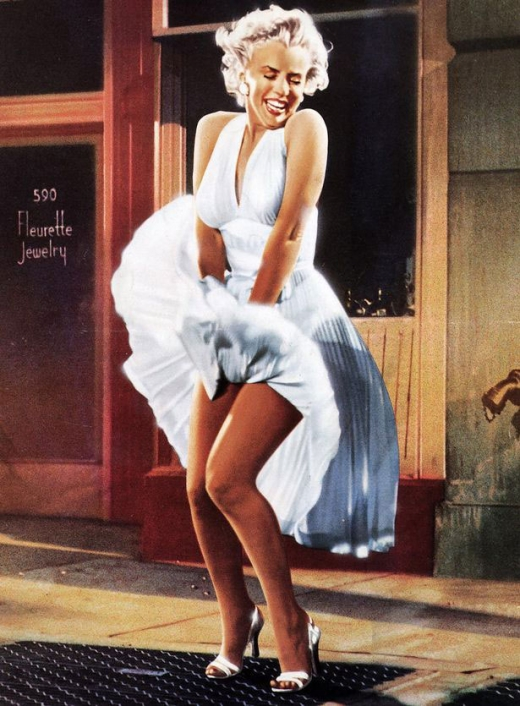

In [203]:
# [STEP 4-1] 참조 사진 열기

# STEP 3을 건너뛰었을 때 친절한 안내를 띄웁니다.
if "POSE_IMAGE" not in globals() or POSE_IMAGE is None:
    raise RuntimeError("POSE_IMAGE가 없습니다. STEP 3-1(드라이브) 또는 3-2(URL)를 먼저 실행하세요.")
if not os.path.exists(POSE_IMAGE):
    raise FileNotFoundError(f"파일을 찾을 수 없습니다: {POSE_IMAGE}\nSTEP 3-1을 다시 실행하세요.")

try:
    pose_src = Image.open(POSE_IMAGE)
except Exception as e:
    raise RuntimeError(
        f"이미지로 읽을 수 없는 파일입니다: {POSE_IMAGE}\n"
        f"jpg / png / webp 형식의 사진을 올렸는지 확인하세요. (원본 오류: {e})"
    )

pose_src = ImageOps.exif_transpose(pose_src)   # 휴대폰 사진 회전 보정
pose_src = pose_src.convert("RGB")             # 컬러 형식 통일

print(f"파일       : {POSE_IMAGE}")
print(f"원본 크기  : {pose_src.size[0]} x {pose_src.size[1]} 픽셀")
print(f"가로세로비 : {pose_src.size[0] / pose_src.size[1]:.2f}  "
      f"({'가로로 김' if pose_src.size[0] > pose_src.size[1] else '세로로 김' if pose_src.size[0] < pose_src.size[1] else '정사각형'})")

# 셀의 마지막 줄에 변수 이름만 쓰면 Colab이 그 값을 화면에 보여 줍니다. (이미지면 그림으로)
pose_src

### 결과 읽는 법

* 올린 사진이 그대로 보이면 정상입니다.
* 사진이 **옆으로 누워** 보이면 → `exif_transpose` 로도 못 잡은 경우입니다.
  원본을 직접 회전시켜 저장한 뒤 STEP 3부터 다시 하세요.
* `FileNotFoundError` → STEP 3-1을 다시 실행하세요.

## 4-2. *(선택)* 인물 부분만 잘라내기

**스켈레톤이 잘 안 잡히는 이유의 1순위는 "인물이 너무 작게 찍혀서"** 입니다.
사진에서 인물 주변만 잘라내면 관절 인식률이 크게 올라갑니다.

일단 4-1 결과가 괜찮아 보이면 **이 셀은 건너뛰고** STEP 4-3으로 가세요.
STEP 5에서 뼈대가 엉망으로 나왔을 때 돌아와서 쓰면 됩니다.

**좌표 읽는 법** — 이미지의 **왼쪽 위가 (0, 0)** 이고, 오른쪽으로 갈수록 `x` 증가,
아래로 갈수록 `y` 증가합니다. `CROP_BOX = (왼쪽, 위, 오른쪽, 아래)` 순서로 픽셀 값을 적습니다.

예: 800×1200 사진에서 가운데 세로 기둥만 남기려면 → `(200, 0, 600, 1200)`

In [204]:
# [STEP 4-2] (선택) 인물 부분만 잘라내기 — 쓸 때만 아래 # 을 지우세요
#
# 예시: samples/pose_01.png (1280x720 애니 캡처)에서 인물만 남기려면
#       CROP_BOX = (150, 0, 1050, 720)   -> 900x720 으로 좁혀집니다.

# CROP_BOX = (150, 0, 1050, 720)    # (왼쪽, 위, 오른쪽, 아래) 픽셀 좌표
#
# before = pose_src.size
# pose_src = pose_src.crop(CROP_BOX)
# print(f"자르기 전: {before[0]} x {before[1]}")
# print(f"자른 후  : {pose_src.size[0]} x {pose_src.size[1]}")
# print()
# print("중요: 크기가 바뀌었으므로 아래 STEP 4-3 셀을 반드시 다시 실행하세요.")
# pose_src

## 4-3. 만들 이미지 크기 자동 계산

**왜 크기를 따로 계산하나요?**

참조 사진이 세로로 길쭉한데 결과를 정사각형으로 만들면
**다리가 잘리거나 몸이 옆으로 퍼져 보입니다.** 그래서 원본의 가로세로 비율을 그대로 유지한 채
크기만 조정합니다.

**두 가지 제약이 있습니다.**

1. **긴 변을 768픽셀 근처로 맞춥니다.**
   FLUX.2 는 1024픽셀 근처에서 가장 좋은 결과를 내지만, 무료 T4에서는 그만큼 느려집니다.
   768이 품질과 속도의 균형점입니다.

2. **가로·세로 모두 16의 배수여야 합니다.**
   FLUX.2 는 이미지를 내부적으로 **1/16 크기로 압축한 공간(latent)** 에서 계산합니다.
   그래서 16으로 나누어떨어지지 않으면 오류가 납니다.
   *(이전 버전의 Stable Diffusion은 8의 배수였습니다. 모델이 바뀌면서 조건도 바뀌었습니다.)*

`MAX_SIDE` 값을 바꾸면 결과 해상도와 소요 시간이 함께 달라집니다.

| `MAX_SIDE` | 결과 | T4에서 걸리는 시간 |
| --- | --- | --- |
| `512` | 빠르지만 디테일 부족 | 약 20~40초 |
| **`768`** | **기본값. 품질과 속도의 균형** | **약 40~90초** |
| `1024` | 가장 좋은 품질 | 약 90~180초 (메모리 부족 위험) |

In [205]:
# [STEP 4-3] 생성할 이미지 크기 자동 계산

MAX_SIDE = 768   # 긴 변의 목표 길이. 느리거나 메모리가 부족하면 512로 낮추세요.
MIN_SIDE = 576   # 짧은 변이 이보다 작아지지 않게 막습니다. (인물이 뭉개지는 것 방지)
ABS_MAX = 1024   # 어떤 경우에도 넘지 않는 한 변의 상한. (메모리 폭주 방지)


def fit_size(width, height, max_side=MAX_SIDE, min_side=MIN_SIDE,
             abs_max=ABS_MAX, multiple=16):
    """원본 비율을 유지하면서 생성 크기를 정한다.
    1) 긴 변을 max_side에 맞춘다
    2) 짧은 변이 min_side보다 작아지면 min_side 기준으로 다시 키운다
    3) 그 결과 긴 변이 abs_max를 넘으면 abs_max로 되돌린다 (2보다 우선)
    4) 16의 배수로 내림한다  <- FLUX.2 의 요구 조건"""
    scale = max_side / max(width, height)
    if min(width, height) * scale < min_side:
        scale = min_side / min(width, height)
    if max(width, height) * scale > abs_max:
        scale = abs_max / max(width, height)
    new_w = max(multiple, int(width * scale) // multiple * multiple)
    new_h = max(multiple, int(height * scale) // multiple * multiple)
    return new_w, new_h


WIDTH, HEIGHT = fit_size(*pose_src.size)
aspect = max(pose_src.size) / min(pose_src.size)

print(f"원본 크기   : {pose_src.size[0]} x {pose_src.size[1]}")
print(f"생성할 크기 : {WIDTH} x {HEIGHT}   <- 이 크기로 그림이 만들어집니다")
print()
print(f"16의 배수 확인 : 가로 {WIDTH} % 16 = {WIDTH % 16}, 세로 {HEIGHT} % 16 = {HEIGHT % 16}  (둘 다 0이어야 정상)")
print(f"비율 유지 확인 : 원본 {pose_src.size[0] / pose_src.size[1]:.3f} -> 생성 {WIDTH / HEIGHT:.3f}")

if aspect > 1.5:
    print()
    print("!" * 66)
    print(f"경고: 가로세로비가 {aspect:.2f} 로 너무 깁니다. (16:9 화면 캡처 등)")
    print()
    print("이대로 생성하면 인물이 화면의 일부만 차지해 작게 그려집니다.")
    print()
    print("해결: STEP 4-2 셀로 돌아가 인물 주변만 잘라내세요.")
    print("      (또는 STEP 5-4의 자동 크롭을 쓰세요.)")
    print("!" * 66)

원본 크기   : 520 x 706
생성할 크기 : 576 x 768   <- 이 크기로 그림이 만들어집니다

16의 배수 확인 : 가로 576 % 16 = 0, 세로 768 % 16 = 0  (둘 다 0이어야 정상)
비율 유지 확인 : 원본 0.737 -> 생성 0.750


---
# STEP 5 — 사진에서 자세(스켈레톤) 뽑아내기

**이 노트북의 핵심 단계입니다.**

## OpenPose가 하는 일

**OpenPose**는 사진 한 장을 보고 사람의 **관절 18곳**의 화면상 좌표를 찾아내는 모델입니다.

```
찾는 관절 18개
  코, 목
  오른쪽 어깨 / 팔꿈치 / 손목        왼쪽 어깨 / 팔꿈치 / 손목
  오른쪽 골반 / 무릎 / 발목          왼쪽 골반 / 무릎 / 발목
  오른쪽 눈 / 귀                     왼쪽 눈 / 귀
```

찾은 점들을 **부위별로 정해진 색**의 선으로 이어서, **검은 배경 위에 막대 인형 같은 그림**을 만듭니다.
이것을 **스켈레톤(skeleton)** 또는 **컨트롤 이미지**라고 부릅니다.
색깔이 부위 정보를 담고 있어서(왼팔은 초록 계열, 오른팔은 주황 계열 등)
다음 단계의 모델이 "어느 선이 어느 팔인지" 구분할 수 있습니다.

## 왜 이게 필요한가

STEP 8에서 이 그림을 **FLUX.2의 참조 이미지**로 넣으면서 이렇게 지시하게 됩니다:

> "이 뼈대와 같은 자세로 사람을 그려라. 단, 뼈대 선과 검은 배경은 그리지 마라."

색깔이 부위 정보를 담고 있어서(왼팔은 초록 계열, 오른팔은 주황 계열 등)
모델이 "어느 선이 어느 팔인지" 구분할 수 있습니다.

> ### 반드시 확인하세요
> 여기서 뼈대가 엉뚱하게 잡히면 **최종 결과도 반드시 엉망이 됩니다.**
> 출력된 스켈레톤이 원본 사진의 자세와 닮았는지 **눈으로 비교한 뒤** 넘어가세요.

## 5-0. OpenPose가 잘 못 잡는 이미지 — 먼저 읽으세요

OpenPose는 **실제 사람 사진 수십만 장으로 학습된 모델**입니다.
사람이 아닌 비율이나 사진이 아닌 화풍에서는 인식률이 뚝 떨어집니다.

| 참조 이미지 종류 | 인식률 | 대처 |
| --- | --- | --- |
| 실사 인물 사진, 전신 | 매우 좋음 | 그대로 진행 |
| 실사 인물 사진, 인물이 작음 | 보통 | **5-4 자동 크롭** |
| **애니메이션 · 일러스트** | **나쁨~보통** | **5-4 자동 크롭** 후에도 나쁘면 사진으로 교체 |
| 3D 렌더링 캐릭터 | 보통 | 5-4 자동 크롭 |
| 극단적 각도(위/아래에서) | 나쁨 | 정면·측면 이미지로 교체 |
| 팔다리가 화면 밖으로 잘림 | 잘린 부위 누락 | 전신이 보이는 이미지로 교체 |

**애니메이션 캡처가 특히 어려운 이유**

* 머리가 몸에 비해 크고 눈·머리카락이 과장되어 **실제 사람 비율과 다릅니다**
* 명암이 평평해서 팔다리의 입체감으로 관절을 추정하기 어렵습니다
* 16:9 화면 캡처는 인물이 화면의 일부만 차지하는 경우가 많습니다

애니 캡처를 쓸 거라면 **인물이 화면을 꽉 채우도록 잘라내는 것이 거의 필수**입니다.
아래 5-4 셀이 그 작업을 자동으로 해 줍니다.

## 5-1. OpenPose 모델 불러오기

인터넷에서 OpenPose 가중치 파일(약 200MB)을 내려받습니다. **첫 실행은 30초~1분** 걸립니다.

> **코드 한 줄 설명**
> `from controlnet_aux.open_pose import OpenposeDetector`
> — `controlnet_aux` 전체를 불러오면 이 노트북에서 안 쓰는 다른 분석 도구
> (깊이 추정, 윤곽선 추출 등)까지 전부 메모리에 올라가면서 오류가 날 수 있습니다.
> 필요한 `open_pose` 모듈만 콕 집어서 가져옵니다.

In [206]:
# [STEP 5-1] OpenPose 모델 불러오기 (첫 실행 30초~1분)

from controlnet_aux.open_pose import OpenposeDetector

print("OpenPose 가중치를 내려받는 중... (첫 실행만 시간이 걸립니다)")
t0 = time.time()

# "lllyasviel/Annotators"는 ControlNet 제작자가 각종 추출 도구 가중치를 모아 둔 공식 저장소입니다.
openpose = OpenposeDetector.from_pretrained("lllyasviel/Annotators")

print(f"OpenPose 준비 완료 ({time.time() - t0:.0f}초)")

OpenPose 가중치를 내려받는 중... (첫 실행만 시간이 걸립니다)
OpenPose 준비 완료 (3초)


## 5-2. 관절 찾아서 스켈레톤 만들기

### 세 가지 켜고 끌 수 있는 옵션

| 옵션 | 기본값 | 켜면 | 언제 켜나 |
| --- | --- | --- | --- |
| `include_body` | `True` | 몸통·팔·다리 관절 18개 | **항상 켜 둡니다** |
| `include_hand` | `False` | 손가락 관절 21개 × 양손 | 손 모양이 중요한 포즈일 때 |
| `include_face` | `False` | 얼굴 윤곽점 70개 | 얼굴 방향·표정까지 따라 하고 싶을 때 |

**`include_hand` 를 켤지 말지**
손가락까지 잡으면 결과의 손 모양이 좋아질 수 있지만, 원본에서 손이 흐릿하거나 가려져 있으면
**엉뚱한 손가락 뼈대가 생겨 결과가 더 망가집니다.** 일단 `False`로 해 보고,
손이 뭉개지면 `True`로 바꿔 비교해 보세요.

**`detect_resolution=512`**
관절을 찾을 때 사진을 몇 픽셀로 줄여서 볼지입니다. 512면 충분하고, 올려도 크게 좋아지지 않으면서
느려집니다.

**마지막 `resize` 가 왜 필요한가**
OpenPose가 만든 스켈레톤과 STEP 4-3에서 정한 생성 크기가 **정확히 같아야** 합니다.
(FLUX.2는 참조 이미지와 결과 이미지의 크기가 같을 때 자세를 가장 잘 맞춥니다.)
크기가 다르면 자세가 미묘하게 어긋난 채로 전달됩니다.

In [207]:
# [STEP 5-2] 관절을 찾아 스켈레톤 이미지 만들기

# STEP 6-3에서 메모리를 비웠다면 openpose 가 None 이 됩니다. 그때는 5-1부터 다시 실행해야 합니다.
if globals().get("openpose") is None:
    raise RuntimeError(
        "OpenPose 모델이 메모리에 없습니다.\n"
        "STEP 5-1 셀을 먼저 실행한 뒤 이 셀을 다시 실행하세요.\n"
        "(STEP 6-3에서 메모리 확보를 위해 해제했을 수 있습니다.)"
    )

t0 = time.time()

pose_map = openpose(
    pose_src,
    include_body=True,     # 몸통·팔·다리 (항상 True)
    include_hand=False,    # 손가락까지 잡기 (손이 뭉개지면 True로 바꿔 비교)
    include_face=False,    # 얼굴 윤곽까지 잡기 (표정을 따라 하고 싶을 때만 True)
    detect_resolution=512, # 관절을 찾을 때 볼 해상도
    output_type="pil",     # 결과를 PIL 이미지로 받기
)

# 생성 크기와 정확히 일치시킵니다.
pose_map = pose_map.resize((WIDTH, HEIGHT), Image.LANCZOS)

print(f"스켈레톤 추출 완료 ({time.time() - t0:.1f}초)")
print(f"스켈레톤 크기: {pose_map.size[0]} x {pose_map.size[1]} (생성 크기와 같아야 정상)")

스켈레톤 추출 완료 (1.4초)
스켈레톤 크기: 576 x 768 (생성 크기와 같아야 정상)


## 5-3. 스켈레톤 확인 — 여기서 꼭 눈으로 보세요

관절을 하나도 못 찾으면 **완전히 검은 이미지**가 나옵니다.
그 경우를 코드가 자동으로 잡아내서 경고를 띄웁니다.

아래 `흰 픽셀 비율` 은 전체 화면에서 뼈대(색깔 선)가 차지하는 넓이입니다.
경험상 **1% 미만이면 인물이 너무 작게 잡힌 것**입니다.

뼈대가 차지하는 화면 비율: 3.65%
----------------------------------------------------------------
성공: 아래 그림이 원본 사진의 자세와 닮았는지 눈으로 확인하세요.


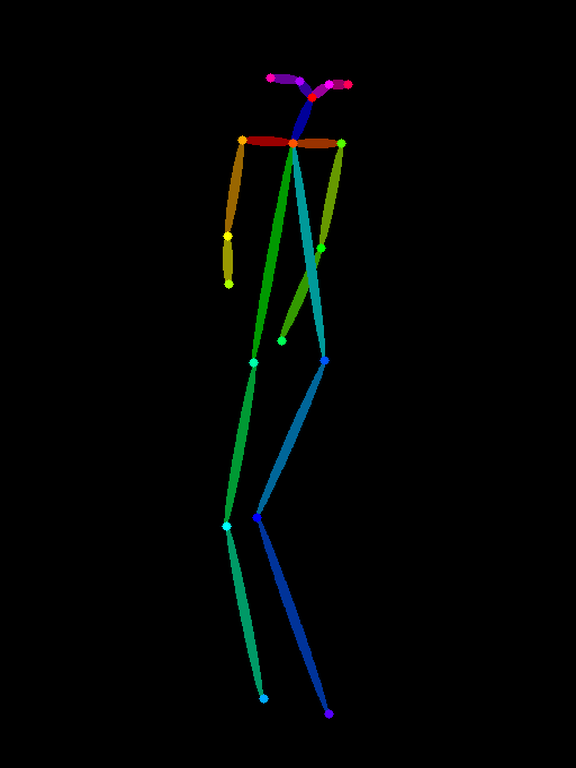

In [208]:
# [STEP 5-3] 스켈레톤 품질 확인 + 화면에 표시

arr = np.asarray(pose_map)
nonblack_ratio = (arr.max(axis=2) > 20).mean()   # 검지 않은 픽셀의 비율

print(f"뼈대가 차지하는 화면 비율: {nonblack_ratio * 100:.2f}%")
print("-" * 64)

if arr.max() == 0:
    print("실패: 관절을 하나도 찾지 못했습니다 (스켈레톤이 완전히 검은색)")
    print()
    print("원인 후보")
    print("  - 인물이 화면에서 너무 작음")
    print("  - 몸이 대부분 가려졌거나 뒷모습·극단적 각도")
    print("  - 사진에 사람이 없음")
    print()
    print("해결: STEP 4-2 셀로 돌아가 인물 주변만 잘라낸 뒤, STEP 4-3 → 5-2 → 5-3을 다시 실행하세요.")
elif nonblack_ratio < 0.01:
    print("주의: 뼈대가 너무 작게 잡혔습니다. 결과가 흐릿하거나 자세가 어긋날 수 있습니다.")
    print("      STEP 4-2로 돌아가 인물 주변만 잘라내면 크게 좋아집니다.")
else:
    print("성공: 아래 그림이 원본 사진의 자세와 닮았는지 눈으로 확인하세요.")

pose_map

### 결과 읽는 법

| 보이는 것 | 뜻 | 할 일 |
| --- | --- | --- |
| 검은 배경에 **알록달록한 막대 인형** | 성공 | STEP 6으로 |
| **완전히 검은 화면** | 인물 인식 실패 | STEP 4-2에서 인물 주변만 크롭 |
| **팔/다리 일부가 빠짐** | 원본에서 가려진 부위 | 그대로 진행 가능. 빠진 부위는 모델이 알아서 그립니다 |
| **막대가 여러 개 뒤엉킴** | 사람이 여러 명으로 인식됨 | 한 사람만 나오게 크롭 |
| **뼈대가 화면 구석에 작게** | 인물이 작음 | 크롭해서 크게 만들기 |

## 5-4. *(결과가 나쁠 때)* 인물 기준 자동 크롭 후 다시 추출

5-3의 뼈대가 **작거나 어긋났다면 이 셀을 실행하세요.** 좌표를 직접 계산할 필요가 없습니다.

### 하는 일

1. 방금 찾은 **관절 좌표로 인물을 감싸는 사각형**을 계산합니다
2. 주위에 18% 여백을 두고 **자동으로 잘라냅니다**
3. 잘린 이미지로 **스켈레톤을 다시 추출**하고, 생성 크기도 다시 계산합니다

인물이 화면을 크게 채우게 되므로 **관절 인식률과 결과 품질이 함께 올라갑니다.**
특히 16:9 화면 캡처처럼 가로로 긴 이미지에서 효과가 큽니다.

> 이 셀은 **여러 번 실행하지 마세요.** 실행할 때마다 더 좁게 잘려 들어갑니다.
> 너무 좁아졌다면 STEP 4-1부터 다시 실행해 원본을 새로 불러오세요.

찾은 사람 수   : 1 (관절이 가장 많은 사람 기준)
사용한 관절 수 : 18개 / 18개
자르는 영역    : (10, 0, 508, 706)
영역 가로세로비: 0.71

자른 뒤 원본   : 498 x 706
생성할 크기    : 576 x 816
뼈대 화면 비율 : 3.70%  (5-3보다 커졌으면 성공)


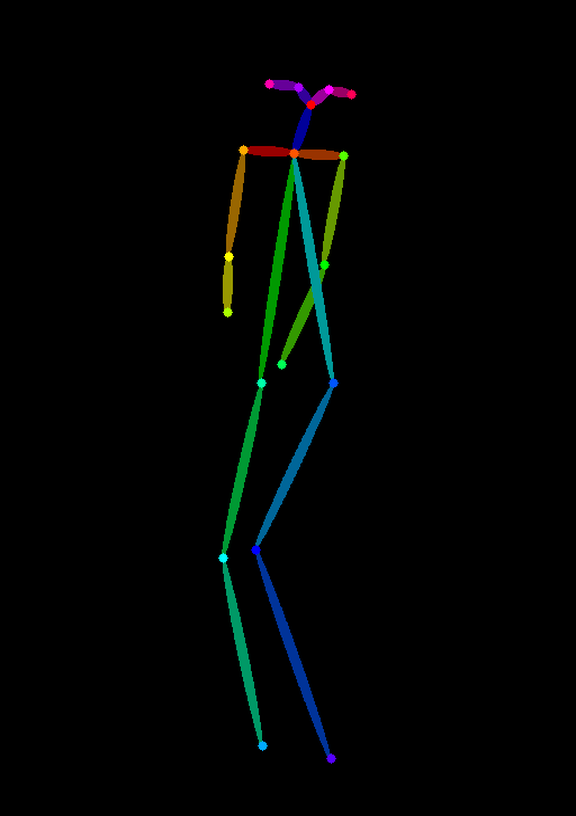

In [209]:
# [STEP 5-4] 인물 기준 자동 크롭 후 재추출 (5-3 결과가 나쁠 때만 실행)

MARGIN = 0.18   # 인물 주위에 남길 여백 비율 (0.18 = 18%). 손발이 잘리면 0.3으로 올리세요.
DETECT_SIDE = 768   # 관절을 찾을 때 볼 최대 크기. 큰 사진에서 느려지는 것을 막습니다.

# STEP 6-3에서 메모리를 비웠다면 openpose 가 None 이 됩니다. 그때는 5-1부터 다시 실행해야 합니다.
if globals().get("openpose") is None:
    raise RuntimeError(
        "OpenPose 모델이 메모리에 없습니다.\n"
        "STEP 5-1 셀을 먼저 실행한 뒤 이 셀을 다시 실행하세요."
    )

# detect_poses 는 PIL 이미지가 아니라 numpy 배열을 받습니다.
# (5-2의 openpose(...) 는 안에서 알아서 바꿔 주지만, 이 함수는 직접 바꿔 넘겨야 합니다.)
probe = pose_src.convert("RGB")
if max(probe.size) > DETECT_SIDE:
    scale = DETECT_SIDE / max(probe.size)
    probe = probe.resize((max(1, int(probe.size[0] * scale)),
                          max(1, int(probe.size[1] * scale))), Image.LANCZOS)

# 돌아오는 관절 좌표는 0~1 비율이라, 줄여서 넣어도 원본 크기에 그대로 대응됩니다.
poses = openpose.detect_poses(np.array(probe, dtype=np.uint8))

if not poses:
    print("관절을 찾지 못해 자동 크롭을 할 수 없습니다.")
    print("-> STEP 4-2에서 직접 좌표를 정해 잘라낸 뒤 4-3 -> 5-2 -> 5-3을 다시 실행하세요.")
else:
    # 관절이 가장 많이 잡힌 사람을 고릅니다. (사람이 여럿일 때 대비)
    try:
        best = max(poses, key=lambda p: sum(1 for k in p.body.keypoints if k is not None))
        pts = [k for k in best.body.keypoints if k is not None]
        xs = [k.x for k in pts]
        ys = [k.y for k in pts]
    except AttributeError as err:
        raise RuntimeError(
            f"관절 좌표를 읽는 방식이 예상과 다릅니다 ({err}).\n"
            "이 셀 대신 STEP 4-2에서 직접 좌표를 정해 잘라내세요."
        )

    W0, H0 = pose_src.size

    # 좌표가 0~1로 정규화되어 있으면 픽셀 단위로 환산합니다.
    if max(xs) <= 1.5 and max(ys) <= 1.5:
        xs = [x * W0 for x in xs]
        ys = [y * H0 for y in ys]

    x0, x1, y0, y1 = min(xs), max(xs), min(ys), max(ys)
    mx, my = (x1 - x0) * MARGIN, (y1 - y0) * MARGIN
    x0, x1, y0, y1 = x0 - mx, x1 + mx, y0 - my, y1 + my

    # 누운 자세처럼 상자가 극단적으로 납작하거나 길쭉하면, 짧은 축을 넓혀 비율을 완화합니다.
    # (이 보정이 없으면 누운 사람에서 1000px 넘게 가로로 긴 그림이 만들어집니다.)
    MAX_ASPECT = 1.6
    bw, bh = x1 - x0, y1 - y0
    if bw / bh > MAX_ASPECT:
        pad = (bw / MAX_ASPECT - bh) / 2
        y0, y1 = y0 - pad, y1 + pad
    elif bh / bw > MAX_ASPECT:
        pad = (bh / MAX_ASPECT - bw) / 2
        x0, x1 = x0 - pad, x1 + pad

    box = (max(0, int(x0)), max(0, int(y0)), min(W0, int(x1)), min(H0, int(y1)))

    print(f"찾은 사람 수   : {len(poses)} (관절이 가장 많은 사람 기준)")
    print(f"사용한 관절 수 : {len(pts)}개 / 18개")
    print(f"자르는 영역    : {box}")
    print(f"영역 가로세로비: {(box[2] - box[0]) / max(1, box[3] - box[1]):.2f}")
    print()

    # 자르고, 크기를 다시 계산하고, 스켈레톤을 다시 뽑습니다.
    pose_src = pose_src.crop(box)
    WIDTH, HEIGHT = fit_size(*pose_src.size)
    pose_map = openpose(pose_src, include_body=True, include_hand=False,
                        include_face=False, detect_resolution=512, output_type="pil")
    pose_map = pose_map.resize((WIDTH, HEIGHT), Image.LANCZOS)

    ratio = (np.asarray(pose_map).max(axis=2) > 20).mean()
    print(f"자른 뒤 원본   : {pose_src.size[0]} x {pose_src.size[1]}")
    print(f"생성할 크기    : {WIDTH} x {HEIGHT}")
    print(f"뼈대 화면 비율 : {ratio * 100:.2f}%  (5-3보다 커졌으면 성공)")

pose_map

### 이 뒤로는

크롭 결과가 만족스러우면 **STEP 6으로 넘어가세요.** (STEP 4-3과 5-2는 이 셀이 이미 다시 해 줬습니다.)

여전히 나쁘다면 참조 이미지 자체가 OpenPose에 어려운 경우입니다. 위 **5-0 주의사항**을 참고해
다른 사진으로 바꾸는 편이 빠릅니다.

---
# STEP 6 — 모델 내려받기 · 생성 엔진 켜기

이제 그림을 그릴 준비를 합니다. **첫 실행은 15~25분** 걸립니다 (모델 파일이 약 11GB).
같은 런타임에서 두 번째로 실행하면 파일이 이미 있으므로 **1분 안에** 끝납니다.

## FLUX.2 는 파일 3개가 모여야 동작합니다

Stable Diffusion은 파일 하나로 끝났지만, FLUX.2 는 **역할이 다른 파일 3개**를 각각 받아 조립합니다.

| 역할 | 파일 | 크기 | 하는 일 |
| --- | --- | --- | --- |
| **디퓨전 모델** | `flux-2-klein-4b-Q4_K_M.gguf` | 2.6GB | 실제로 그림을 그리는 **화가** |
| **텍스트 인코더** | `qwen_3_4b.safetensors` | 8GB | 프롬프트(영어 문장)를 숫자로 바꾸는 **통역사** |
| **VAE** | `flux2-vae.safetensors` | 0.33GB | 압축된 결과를 실제 픽셀 그림으로 펼치는 **현상소** |

> **왜 통역사가 화가보다 크나요?** FLUX.2 의 텍스트 인코더는 Qwen3-4B 라는 **작은 언어 모델**입니다.
> 단어를 하나씩 바꾸는 게 아니라 문장 전체의 뜻을 이해하기 때문에, 긴 문장도 잘 알아듣습니다.
> 이전 버전(SD 1.5)이 약 77토큰까지만 읽었던 것과 크게 다른 점입니다.

## 자세는 어떻게 전달되나요?

이전 버전의 ControlNet과 달리, FLUX.2 는 **스켈레톤 그림 자체를 "참조 이미지"로 받아들입니다.**

```
 [프롬프트]  "기사를 그려라"        ─┐
                                      ├─▶ FLUX.2 ─▶ 결과
 [참조 이미지]  스켈레톤 그림       ─┘
 [지시 문장]  "이 뼈대와 같은 자세로, 뼈대 선 자체는 그리지 마라"
```

그래서 STEP 7에서 정하는 `POSE_STRICTNESS` 는 숫자가 아니라 **지시 문장의 강도**입니다.
이 지시 문장은 STEP 6-4에서 만드는 생성 함수가 프롬프트 앞에 자동으로 붙여 줍니다.

## 6-1. 쓸 모델 파일 정하기

여기서는 **파일 이름과 내려받을 주소만** 정합니다. 실제 내려받기는 6-2에서 합니다.

### `USE_GGUF` — 압축본을 쓸지 원본을 쓸지

| 값 | 파일 | 크기 | 특징 |
| --- | --- | --- | --- |
| **`True`** *(기본)* | `...Q4_K_M.gguf` | **2.6GB** | 4비트로 압축한 것. **무료 T4에서 권장** |
| `False` | `...fp8.safetensors` | 4.1GB | 8비트 원본. 품질이 아주 조금 좋지만 메모리를 더 씀 |

`True` 로 실패할 때만 `False` 로 바꿔 보세요. (바꾸면 6-1 → 6-2 → 6-3 을 다시 실행해야 합니다.)

> **GGUF** — 원래 언어 모델을 개인 PC에서 돌리려고 만든 압축 파일 형식입니다.
> 지금은 이미지 모델에도 널리 쓰입니다. ComfyUI 는 STEP 1에서 깐 부품으로 이 형식을 읽습니다.

In [210]:
# [STEP 6-1] 쓸 모델 파일 정하기

USE_GGUF = True   # True = 2.6GB 압축본 (권장) / False = 4.1GB fp8 원본

# --- 그림을 그리는 디퓨전 모델 ---
if USE_GGUF:
    UNET_NAME = "flux-2-klein-4b-Q4_K_M.gguf"
    UNET_LOADER = "UnetLoaderGGUF"          # STEP 1에서 깐 GGUF 부품이 담당
    UNET_URL = ("https://huggingface.co/unsloth/FLUX.2-klein-4B-GGUF/"
                "resolve/main/flux-2-klein-4b-Q4_K_M.gguf")
    UNET_GB = 2.6
else:
    UNET_NAME = "flux-2-klein-4b-fp8.safetensors"
    UNET_LOADER = "UNETLoader"               # ComfyUI 기본 부품
    UNET_URL = ("https://huggingface.co/black-forest-labs/FLUX.2-klein-4b-fp8/"
                "resolve/main/flux-2-klein-4b-fp8.safetensors")
    UNET_GB = 4.1

# --- 프롬프트를 숫자로 바꾸는 텍스트 인코더 (Qwen3-4B) ---
CLIP_NAME = "qwen_3_4b.safetensors"
CLIP_URL = ("https://huggingface.co/Comfy-Org/vae-text-encorder-for-flux-klein-4b/"
            "resolve/main/split_files/text_encoders/qwen_3_4b.safetensors")

# --- 압축된 결과를 실제 그림으로 펼치는 VAE ---
VAE_NAME = "flux2-vae.safetensors"
VAE_URL = ("https://huggingface.co/Comfy-Org/vae-text-encorder-for-flux-klein-4b/"
           "resolve/main/split_files/vae/flux2-vae.safetensors")

# ComfyUI 가 모델을 찾아가는 표준 폴더 구조입니다. 이름과 위치를 바꾸면 못 찾습니다.
MODEL_FILES = [
    ("디퓨전 모델", UNET_URL, f"{COMFY_DIR}/models/diffusion_models/{UNET_NAME}", UNET_GB),
    ("텍스트 인코더", CLIP_URL, f"{COMFY_DIR}/models/text_encoders/{CLIP_NAME}", 8.0),
    ("VAE", VAE_URL, f"{COMFY_DIR}/models/vae/{VAE_NAME}", 0.34),
]

print(f"디퓨전 모델   : {UNET_NAME}  ({UNET_GB} GB, 로더={UNET_LOADER})")
print(f"텍스트 인코더 : {CLIP_NAME}  (8.0 GB)")
print(f"VAE           : {VAE_NAME}  (0.34 GB)")
print()
print(f"합계 약 {UNET_GB + 8.34:.1f} GB 를 내려받습니다. 다음 6-2 셀에서 진행합니다.")

디퓨전 모델   : flux-2-klein-4b-Q4_K_M.gguf  (2.6 GB, 로더=UnetLoaderGGUF)
텍스트 인코더 : qwen_3_4b.safetensors  (8.0 GB)
VAE           : flux2-vae.safetensors  (0.34 GB)

합계 약 10.9 GB 를 내려받습니다. 다음 6-2 셀에서 진행합니다.


## 6-2. 모델 파일 내려받기 (첫 실행 15~25분)

**이 노트북에서 가장 오래 걸리는 단계입니다.** 약 11GB를 받습니다.

* 진행 막대가 파일마다 하나씩, 총 3번 지나갑니다.
* **이미 받아 둔 파일은 건너뜁니다.** 런타임이 살아 있는 동안은 다시 받지 않습니다.
* 중간에 끊겨도 `.part` 라는 임시 파일에 이어받기 때문에, 다시 실행하면 **이어서** 받습니다.

> **런타임이 끊기면 이 11GB도 같이 사라집니다.** Colab의 정해진 동작이라 피할 수 없습니다.
> 그래서 한 번 연결했을 때 실험을 몰아서 하는 편이 좋습니다.

In [211]:
# [STEP 6-2] 모델 파일 내려받기 (첫 실행 15~25분)

t_all = time.time()

for i, (label, url, dest, gb) in enumerate(MODEL_FILES, start=1):
    os.makedirs(os.path.dirname(dest), exist_ok=True)

    # 이미 제대로 받아 둔 파일이면 건너뜁니다.
    if os.path.exists(dest) and os.path.getsize(dest) > 1_000_000:
        print(f"[{i}/3] {label}: 이미 있음 ({os.path.getsize(dest) / 1e9:.2f} GB) — 건너뜀")
        continue

    print(f"[{i}/3] {label} 내려받는 중... 약 {gb} GB")
    tmp = dest + ".part"                      # 받는 도중에는 .part 로 두고,
    !wget -q --show-progress -c -O "{tmp}" "{url}"
    if os.path.exists(tmp) and os.path.getsize(tmp) > 1_000_000:
        os.replace(tmp, dest)                 # 다 받은 뒤에만 진짜 이름으로 바꿉니다.
        print(f"      완료 ({os.path.getsize(dest) / 1e9:.2f} GB)")
    else:
        print(f"      실패 — 이 셀을 다시 실행하면 이어받습니다.")

print(f"\n내려받기 단계 종료 (누적 {time.time() - t_all:.0f}초)")
print("-" * 66)

ok = True
for label, url, dest, gb in MODEL_FILES:
    if os.path.exists(dest) and os.path.getsize(dest) > 1_000_000:
        print(f"  정상   {label:<14} {os.path.getsize(dest) / 1e9:>6.2f} GB  {os.path.basename(dest)}")
    else:
        print(f"  !! 없음 {label:<14} {os.path.basename(dest)}")
        ok = False

print()
print("모델 파일 준비 완료 — STEP 6-3으로 넘어가세요." if ok
      else "받지 못한 파일이 있습니다. 이 셀을 다시 실행하세요.")

[1/3] 디퓨전 모델: 이미 있음 (2.60 GB) — 건너뜀
[2/3] 텍스트 인코더: 이미 있음 (8.04 GB) — 건너뜀
[3/3] VAE: 이미 있음 (0.34 GB) — 건너뜀

내려받기 단계 종료 (누적 0초)
------------------------------------------------------------------
  정상   디퓨전 모델           2.60 GB  flux-2-klein-4b-Q4_K_M.gguf
  정상   텍스트 인코더          8.04 GB  qwen_3_4b.safetensors
  정상   VAE              0.34 GB  flux2-vae.safetensors

모델 파일 준비 완료 — STEP 6-3으로 넘어가세요.


## 6-3. 생성 엔진(ComfyUI) 켜기

ComfyUI를 **뒤에서 조용히 돌아가는 프로그램**으로 띄웁니다.
노트북과는 별개의 프로그램이고, 서로 `http://127.0.0.1:8188` 이라는 **내부 주소로만** 대화합니다.
이 주소는 Colab 서버 안에서만 통하며 외부에는 열리지 않습니다.

### 이 셀이 하는 일

1. 혹시 이미 떠 있는 예전 서버가 있으면 정리합니다
2. **자세 추출 모델(OpenPose)을 메모리에서 내립니다** — 아래 설명 참고
3. ComfyUI를 실행하고, 준비될 때까지 기다립니다 (보통 30초~1분)
4. 필요한 부품(노드) 16개가 전부 있는지 확인합니다

> **왜 OpenPose를 메모리에서 내리나요?**
> Colab 무료 환경의 시스템 메모리는 약 13GB인데, 텍스트 인코더 하나만 8GB입니다.
> 자세 추출은 STEP 5에서 이미 끝났으니 자리를 비켜 주는 편이 안전합니다.
> **참조 사진을 바꿔서 자세를 다시 뽑고 싶다면 STEP 5-1부터 다시 실행**하면 됩니다.
> 메모리에 여유가 있어 굳이 내리고 싶지 않다면 `FREE_POSE_MODEL = False` 로 바꾸세요.

### 오래 걸린다면

`ComfyUI 기동 대기 중` 이 3분 넘게 이어지면 실패한 것입니다.
셀이 알아서 로그 마지막 부분을 보여 주니, 거기에 적힌 오류를 보고 부록 A를 참고하세요.

In [212]:
# [STEP 6-3] 생성 엔진(ComfyUI) 켜기

import gc

COMFY_SERVER = "http://127.0.0.1:8188"   # Colab 서버 내부에서만 통하는 주소
COMFY_LOG = "/content/comfyui.log"       # ComfyUI가 남기는 기록 파일
EXTRA_ARGS = []                          # 메모리 부족(OOM)이 나면 ["--lowvram"] 로 바꾸세요
FREE_POSE_MODEL = True                   # 자세 추출 모델을 메모리에서 내릴지 여부

# (1) 예전에 띄운 서버가 남아 있으면 정리합니다.
if globals().get("comfy_proc") is not None:
    comfy_proc.terminate()
    time.sleep(2)
subprocess.run(["pkill", "-f", "main.py --listen"], capture_output=True)
time.sleep(2)

# (2) 자세 추출 모델을 메모리에서 내려 자리를 확보합니다.
if FREE_POSE_MODEL and globals().get("openpose") is not None:
    openpose = None
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print("OpenPose 모델을 메모리에서 내렸습니다.")
    print("  -> 자세를 다시 뽑으려면 STEP 5-1부터 다시 실행하세요.")
    print()

# (3) ComfyUI 를 뒤에서 실행합니다. (노트북의 작업 폴더는 그대로 둡니다)
_log = open(COMFY_LOG, "w")
comfy_proc = subprocess.Popen(
    [sys.executable, "main.py", "--listen", "127.0.0.1", "--port", "8188", *EXTRA_ARGS],
    cwd=COMFY_DIR, stdout=_log, stderr=subprocess.STDOUT,
)

print("ComfyUI 기동 대기 중...", end="", flush=True)
ready = False
for _ in range(90):                       # 최대 약 3분 기다립니다
    time.sleep(2)
    print(".", end="", flush=True)
    try:
        if requests.get(COMFY_SERVER, timeout=5).status_code == 200:
            ready = True
            break
    except requests.RequestException:
        pass
print()

if not ready:
    print("!" * 66)
    print("ComfyUI 서버가 뜨지 않았습니다. 로그 마지막 부분:")
    print("!" * 66)
    print(open(COMFY_LOG, encoding="utf-8", errors="replace").read()[-2000:])
else:
    print(f"ComfyUI 준비 완료 ({COMFY_SERVER})")

    # (4) 우리가 쓸 부품(노드)이 전부 있는지 확인합니다.
    REQUIRED_NODES = [
        UNET_LOADER, "CLIPLoader", "VAELoader", "LoadImage", "VAEEncode",
        "CLIPTextEncode", "ConditioningZeroOut", "ReferenceLatent",
        "EmptyFlux2LatentImage", "Flux2Scheduler", "KSamplerSelect",
        "RandomNoise", "CFGGuider", "SamplerCustomAdvanced", "VAEDecode", "SaveImage",
    ]
    info = requests.get(f"{COMFY_SERVER}/object_info", timeout=120).json()
    missing = [n for n in REQUIRED_NODES if n not in info]

    print(f"필요한 부품 {len(REQUIRED_NODES)}개 중 {len(REQUIRED_NODES) - len(missing)}개 확인")
    if missing:
        print()
        print("!" * 66)
        print(f"없는 부품: {missing}")
        if UNET_LOADER in missing:
            print("  -> GGUF 부품이 안 깔렸습니다. STEP 1-1을 다시 실행한 뒤 이 셀을 다시 실행하세요.")
        else:
            print("  -> ComfyUI 버전 문제입니다. 부록 A를 참고하세요.")
        print("!" * 66)
    else:
        print("\n생성 엔진 준비 완료 — STEP 6-4로 넘어가세요.")

OpenPose 모델을 메모리에서 내렸습니다.
  -> 자세를 다시 뽑으려면 STEP 5-1부터 다시 실행하세요.

ComfyUI 기동 대기 중..........
ComfyUI 준비 완료 (http://127.0.0.1:8188)
필요한 부품 16개 중 16개 확인

생성 엔진 준비 완료 — STEP 6-4로 넘어가세요.


## 6-4. 생성 함수 만들기

여기서 만드는 `flux2_generate()` 함수 하나를 **STEP 8과 STEP 10이 함께 씁니다.**
이 셀은 함수를 정의만 할 뿐, 그림을 만들지는 않습니다. (실행해도 몇 초면 끝납니다.)

### 함수 안에서 일어나는 일

```
 ① 스켈레톤 그림을 ComfyUI에 업로드
 ② "부품을 이렇게 연결하라"는 설계도(워크플로우)를 조립
 ③ 설계도를 ComfyUI에 보내고 작업 번호를 받음
 ④ 다 됐는지 2초마다 물어보며 기다림
 ⑤ 완성된 그림을 받아 와 노트북으로 돌려줌
```

### 부품 연결 설계도

ComfyUI는 부품(노드)을 선으로 이어 붙여 동작합니다. 우리가 조립하는 연결은 이렇습니다.

```
  디퓨전 모델 ─────────────────────────────┐
  텍스트 인코더 ─▶ 프롬프트 인코딩 ─┐        │
                                    ├─▶ 참조 latent 붙이기 ─▶ 샘플러 ─▶ VAE ─▶ 결과
  스켈레톤 ─▶ VAE 인코딩 ───────────┘        │
  빈 캔버스 · 단계 계획 · 시드 ──────────────┘
```

여기서 **참조 latent 붙이기**(`ReferenceLatent`)가 이 노트북의 핵심입니다.
스켈레톤 그림을 모델이 읽을 수 있는 형태로 바꿔서, "그리는 내내 이 그림을 보고 있어라"라고 매달아 둡니다.

### 모델에게 실제로 보내는 문장

프롬프트만 그대로 보내는 것이 아니라, 뒤에 지시 문장 두 개를 자동으로 이어 붙입니다.
**순서가 중요합니다.**

```
 ① 내가 쓴 프롬프트        "A knight in silver armor on a misty battlefield..."
 ② 자세 지시               "Pose: 이 참조 도면에 있는 자세로 몸을 두어라"
 ③ 도면 금지               "참조 이미지는 그림의 일부가 아니다. 도면일 뿐이다.
                            뼈대·점·선·검은 배경을 결과에 절대 그리지 마라"
```

**왜 이 순서인가** — 예전에는 ③②① 순서로, "이 참조 이미지는 골격이다"가 맨 앞에 있었습니다.
그러니 모델이 **가장 먼저 읽은 것이 '골격'** 이라, 그것을 그려야 할 대상으로 오해해서
결과 위에 알록달록한 막대기를 얹어 버리는 일이 생겼습니다.
지금은 **그릴 장면을 먼저** 말하고, 도면 이야기는 "그리지 마라"와 함께 뒤에서 못 박습니다.

### `POSE_STRICTNESS` 3단계

위 ②번 문장만 달라집니다. ③번 금지 문장은 **세 경우 모두 똑같이** 붙습니다.

| 값 | ②번 지시의 뜻 |
| --- | --- |
| `"strict"` | "관절 위치·팔다리 각도·머리 방향까지 **정확히 똑같이**" |
| **`"normal"`** | "이 자세로 몸을 두어라" *(기본값)* |
| `"loose"` | "자세는 참고만 해라" |

> 결과에 뼈대가 비친다면 `"strict"` 를 `"normal"` 로 **내려** 보세요.
> 엄격하게 지시할수록 모델이 참조 이미지를 그대로 베끼려는 경향이 강해집니다.

In [213]:
# [STEP 6-4] 생성 함수 만들기 (정의만 합니다 — 그림은 STEP 8에서)

import hashlib   # 같은 스켈레톤인지 구분하는 지문을 만들 때 사용

# 프롬프트 뒤에 붙일 지시 문장. 영어로 써야 모델이 알아듣습니다.
#
# 순서가 중요합니다. 예전에는 "이 참조 이미지는 골격이다" 로 시작했는데,
# 모델이 가장 먼저 읽은 것이 '골격'이라 그것을 그려야 할 대상으로 오해했습니다.
# 지금은 [그릴 장면] -> [자세만 가져와라] -> [도면은 절대 그리지 마라] 순서입니다.

POSE_INSTRUCTION = {
    "strict": (
        " Pose: put the person's body in exactly the pose shown in the attached reference "
        "diagram - same joint positions, same limb angles, same head direction."
    ),
    "normal": (
        " Pose: put the person's body in the pose shown in the attached reference diagram."
    ),
    "loose": (
        " Pose: use the attached reference diagram only as a loose hint for the body posture."
    ),
}

# 세 단계 모두에 똑같이 붙는 금지 문장. 이것이 결과에 뼈대 선이 나오는 것을 막습니다.
NO_SKELETON = (
    " The attached image is NOT part of the picture. It is only a technical pose diagram: "
    "a stick figure drawn with colored dots and straight colored lines on a plain black "
    "background. Take the body posture from it and nothing else. "
    "The final image must contain no skeleton, no stick figure, no colored joint dots, "
    "no straight colored lines, no wireframe, no overlay and no black diagram background. "
    "The final image is an ordinary photograph or artwork of the scene described above, "
    "showing a real, fully rendered person whose body happens to be in that posture."
)


def _comfy_upload(pil_img):
    """스켈레톤 그림을 ComfyUI 서버에 올리고, 서버가 부르는 이름을 돌려준다.

    파일 이름에 그림 내용의 지문(해시)을 넣는다. 그래서
      - 같은 스켈레톤을 여러 번 쓰면 같은 이름 -> ComfyUI가 캐시를 재사용해 빠르다
      - 참조 사진을 바꾸면 이름도 바뀌므로 -> 옛 그림이 잘못 재사용될 일이 없다
    """
    buf = io.BytesIO()
    pil_img.convert("RGB").save(buf, format="PNG")
    name = f"pose_skeleton_{hashlib.md5(buf.getvalue()).hexdigest()[:8]}.png"
    buf.seek(0)
    r = requests.post(
        f"{COMFY_SERVER}/upload/image",
        files={"image": (name, buf, "image/png")},
        data={"overwrite": "true", "type": "input"},
        timeout=120,
    )
    r.raise_for_status()
    info = r.json()
    sub = info.get("subfolder", "")
    return f"{sub}/{info['name']}" if sub else info["name"]


def _build_workflow(ref_name, full_prompt, negative, width, height, steps, cfg, seed):
    """ComfyUI가 이해하는 '부품 연결 설계도'를 딕셔너리로 만든다.
    ["3", 0] 은 '3번 부품의 0번째 출력을 여기에 꽂아라'는 뜻이다."""
    unet_inputs = {"unet_name": UNET_NAME}
    if UNET_LOADER == "UNETLoader":          # 기본 로더는 자료형 지정이 하나 더 필요합니다.
        unet_inputs["weight_dtype"] = "default"

    wf = {
        "1": {"class_type": UNET_LOADER, "inputs": unet_inputs},                                  # 화가
        "2": {"class_type": "CLIPLoader", "inputs": {"clip_name": CLIP_NAME, "type": "flux2"}},   # 통역사
        "3": {"class_type": "VAELoader", "inputs": {"vae_name": VAE_NAME}},                       # 현상소
        "4": {"class_type": "LoadImage", "inputs": {"image": ref_name}},                          # 스켈레톤 불러오기
        "5": {"class_type": "VAEEncode", "inputs": {"pixels": ["4", 0], "vae": ["3", 0]}},        # 스켈레톤을 모델 언어로
        "6": {"class_type": "CLIPTextEncode", "inputs": {"clip": ["2", 0], "text": full_prompt}}, # 프롬프트를 숫자로
        # 7번(네거티브)은 아래에서 cfg 값에 따라 다르게 채웁니다.
        "8": {"class_type": "ReferenceLatent", "inputs": {"conditioning": ["6", 0], "latent": ["5", 0]}},
        "9": {"class_type": "ReferenceLatent", "inputs": {"conditioning": ["7", 0], "latent": ["5", 0]}},
        "10": {"class_type": "EmptyFlux2LatentImage",
               "inputs": {"width": int(width), "height": int(height), "batch_size": 1}},          # 빈 캔버스
        "11": {"class_type": "Flux2Scheduler",
               "inputs": {"steps": int(steps), "width": int(width), "height": int(height)}},      # 단계 계획
        "12": {"class_type": "KSamplerSelect", "inputs": {"sampler_name": "euler"}},              # 그리는 방식
        "13": {"class_type": "RandomNoise", "inputs": {"noise_seed": int(seed)}},                 # 시작 노이즈
        "14": {"class_type": "CFGGuider",
               "inputs": {"model": ["1", 0], "positive": ["8", 0], "negative": ["9", 0],
                          "cfg": float(cfg)}},                                                   # 방향 잡기
        "15": {"class_type": "SamplerCustomAdvanced",
               "inputs": {"noise": ["13", 0], "guider": ["14", 0], "sampler": ["12", 0],
                          "sigmas": ["11", 0], "latent_image": ["10", 0]}},                       # 실제 생성
        "16": {"class_type": "VAEDecode", "inputs": {"samples": ["15", 0], "vae": ["3", 0]}},     # 그림으로 펼치기
        "17": {"class_type": "SaveImage",
               "inputs": {"images": ["16", 0], "filename_prefix": "pose_flux2"}},                 # 저장
    }

    # 네거티브 프롬프트는 cfg 가 1.0 을 넘을 때만 실제로 힘을 씁니다. (자세한 설명은 STEP 7-2)
    if cfg > 1.0:
        wf["7"] = {"class_type": "CLIPTextEncode", "inputs": {"clip": ["2", 0], "text": negative or ""}}
    else:
        wf["7"] = {"class_type": "ConditioningZeroOut", "inputs": {"conditioning": ["6", 0]}}
    return wf


def flux2_generate(prompt, skeleton, width, height, steps, cfg, seed,
                   negative="", strictness="normal", timeout_s=1200, quiet=False):
    """프롬프트 + 스켈레톤 -> 완성된 PIL 이미지.  (이미지, 걸린 초) 를 돌려준다."""
    if strictness not in POSE_INSTRUCTION:
        raise ValueError(f"POSE_STRICTNESS 는 {list(POSE_INSTRUCTION)} 중 하나여야 합니다.")

    # [그릴 장면] + [자세 지시] + [도면 금지] 순서로 이어 붙입니다.
    full_prompt = prompt + POSE_INSTRUCTION[strictness] + NO_SKELETON
    ref_name = _comfy_upload(skeleton)
    workflow = _build_workflow(ref_name, full_prompt, negative, width, height, steps, cfg, seed)

    # (1) 설계도를 보내 작업을 등록합니다.
    r = requests.post(f"{COMFY_SERVER}/prompt",
                      json={"prompt": workflow, "client_id": "pose-image-tool"}, timeout=60)
    if r.status_code != 200:
        raise RuntimeError("ComfyUI가 요청을 거부했습니다:\n" + r.text[:1500])
    pid = r.json()["prompt_id"]

    # (2) 끝날 때까지 2초마다 물어봅니다. 첫 실행은 모델을 메모리에 올리느라 몇 분 걸립니다.
    t0 = time.time()
    img_info = None
    while img_info is None:
        if time.time() - t0 > timeout_s:
            raise TimeoutError(
                f"{timeout_s}초를 넘겼습니다. ComfyUI 로그를 확인하세요:\n"
                f"  print(open('{COMFY_LOG}').read()[-3000:])"
            )
        time.sleep(2)
        if not quiet and int(time.time() - t0) % 20 < 2:
            print(f"  생성 중... {time.time() - t0:.0f}초", end="\r", flush=True)
        try:
            hist = requests.get(f"{COMFY_SERVER}/history/{pid}", timeout=30).json()
        except requests.RequestException:
            continue
        if pid not in hist:
            continue
        entry = hist[pid]
        status = entry.get("status", {})
        if status.get("status_str") == "error":
            raise RuntimeError("ComfyUI 실행 중 오류:\n"
                               + json.dumps(status.get("messages", []), ensure_ascii=False)[:2000])
        images = entry.get("outputs", {}).get("17", {}).get("images", [])
        if not images:
            raise RuntimeError("작업은 끝났는데 결과 이미지가 없습니다. ComfyUI 로그를 확인하세요.")
        img_info = images[0]

    # (3) 완성된 그림을 받아 옵니다.
    query = urllib.parse.urlencode({
        "filename": img_info["filename"],
        "subfolder": img_info.get("subfolder", ""),
        "type": img_info.get("type", "output"),
    })
    rr = requests.get(f"{COMFY_SERVER}/view?{query}", timeout=180)
    rr.raise_for_status()
    return Image.open(io.BytesIO(rr.content)).convert("RGB"), time.time() - t0


print("생성 함수 준비 완료 — STEP 7로 넘어가세요.")
print(f"  자세 강도 선택지: {list(POSE_INSTRUCTION)}")

생성 함수 준비 완료 — STEP 7로 넘어가세요.
  자세 강도 선택지: ['strict', 'normal', 'loose']


---
# STEP 7 — 무엇을 그릴지 정하기

**이 노트북에서 여러분이 실제로 계속 손대게 될 부분입니다.**
STEP 7 → STEP 8 → STEP 9 를 반복하며 원하는 결과를 찾아 가면 됩니다.

## 7-1. 프롬프트 — 무엇을 그릴까

**자세는 이미 스켈레톤이 책임지고 있습니다.** 그러니 프롬프트에는 **나머지 전부**를 씁니다.

### 이전 버전과 쓰는 방식이 다릅니다

FLUX.2 의 통역사(Qwen3-4B)는 **작은 언어 모델**이라 문장을 문장으로 이해합니다.

| | 이전 (SD 1.5) | 지금 (FLUX.2) |
| --- | --- | --- |
| 잘 먹히는 형태 | `knight, silver armor, misty, 4k` 처럼 **단어 나열** | **완전한 문장** |
| 길이 제한 | 약 77토큰(단어 60개)에서 잘림 | 훨씬 넉넉함. 서너 문장도 괜찮음 |
| 품질 강조 단어 | `masterpiece, best quality, 8k` 가 도움이 됨 | **거의 의미 없음.** 쓰지 않아도 됨 |
| 위치·관계 표현 | 잘 못 알아들음 | `holding a lantern in the left hand` 처럼 **구체적 지시가 통함** |

### 이렇게 쓰세요

```
[누가 / 무엇을 입고] 가 [어디서] 있는 장면. [조명]. [화풍].
```

예시:

> `A knight in ornate silver armor with a windswept red cape, standing on a misty battlefield at dawn. Warm rim light from behind. Fantasy concept art style.`

### 규칙

* **반드시 영어로 씁니다.** 한국어도 조금은 알아듣지만 품질이 확연히 떨어집니다.
* **문장으로 씁니다.** 단어만 나열해도 되지만, 문장이 더 정확합니다.
* 사람이 한 명만 나오길 원하면 `A single person...` 처럼 **숫자를 명시**하세요.
* 자세는 적지 않아도 됩니다 — 스켈레톤과 지시 문장이 이미 담당합니다.
  다만 특히 살리고 싶은 동작이 있으면 한 번 더 적어도 해롭지 않습니다.

In [232]:
# [STEP 7-1] 프롬프트 — 무엇을 그릴지 (영어 문장으로!)

PROMPT = (
    "a young male waiting in front of a public restroom, urgent expression, holding his crotch, looking around, " \
    "sweating, tense and very anxious. comical and exaggerated, cartoon style, funny, humorous," \
    "simple cartoonish background, clear lines, simple colors" \
)

print("프롬프트:")
print(f"  {PROMPT}")
print(f"\n대략 단어 수: {len(PROMPT.split())}개 (FLUX.2는 길어도 괜찮습니다)")

프롬프트:
  a young male waiting in front of a public restroom, urgent expression, holding his crotch, looking around, sweating, tense and very anxious. comical and exaggerated, cartoon style, funny, humorous,simple cartoonish background, clear lines, simple colors

대략 단어 수: 35개 (FLUX.2는 길어도 괜찮습니다)


## 7-2. 네거티브 프롬프트 — 무엇을 피할까

**"이런 건 그리지 마라"** 목록입니다.

### 먼저 알아야 할 것 — 기본 설정에서는 **작동하지 않습니다**

FLUX.2 klein 4B는 **distilled(증류) 모델**입니다.
*"큰 모델이 하는 일을 작은 모델에게 속성으로 가르친 것"* 이라고 보면 됩니다.
이런 모델은 단계 수를 크게 줄이는 대신, **네거티브 프롬프트를 쓰는 회로를 떼어 냈습니다.**

그래서 STEP 7-3의 `GUIDANCE` 가 **`1.0` 이면 이 칸의 내용은 무시됩니다.**
`1.0` 을 넘겨야 네거티브가 실제로 작동하지만, 그만큼 **생성 시간이 약 2배**가 되고
distilled 모델 특성상 결과가 오히려 나빠지는 일도 많습니다.

| `GUIDANCE` | 네거티브 | 속도 | 권장 |
| --- | --- | --- | --- |
| **`1.0`** | 무시됨 | **기준** | **기본값. 대부분 이걸로 충분합니다** |
| `1.5`~`3.0` | 작동함 | 약 2배 느림 | 원치 않는 요소가 계속 나올 때만 |

**대신 이렇게 하세요** — FLUX.2 는 문장을 이해하므로, 피하고 싶은 것을 **프롬프트 안에 직접**
`no text, no watermark` 또는 `the background is empty` 처럼 적는 편이 더 잘 듣습니다.

아래 값은 `GUIDANCE` 를 올렸을 때를 대비해 준비만 해 두는 것입니다.

In [228]:
# [STEP 7-2] 네거티브 프롬프트 — 무엇을 피할지
#            (GUIDANCE = 1.0 이면 무시됩니다. 위 설명 참고)

NEGATIVE_PROMPT = (
    "colored skeleton lines, stick figure, black background, "
    "bad anatomy, extra limbs, missing limbs, deformed hands, deformed face, "
    "watermark, text, signature, blurry, lowres, earth"
)

print("네거티브 프롬프트:")
print(f"  {NEGATIVE_PROMPT}")

네거티브 프롬프트:
  colored skeleton lines, stick figure, black background, bad anatomy, extra limbs, missing limbs, deformed hands, deformed face, watermark, text, signature, blurry, lowres, earth


## 7-3. 숫자 설정

| 변수 | 뜻 | 추천 | 올리면 | 내리면 |
| --- | --- | --- | --- | --- |
| `STEPS` | 노이즈를 걷어내는 횟수 | **4** | 조금 정교해짐 · 느려짐 | 거칠어짐 · 빨라짐 |
| `GUIDANCE` | 프롬프트를 얼마나 곧이곧대로 따를지 (CFG) | **1.0** | 네거티브가 작동 · **2배 느려짐** | — |
| `POSE_STRICTNESS` | **참조 자세를 얼마나 엄격히 지킬지** | **`"normal"`** | `"strict"` → 자세 정확 · 뻣뻣해짐 | `"loose"` → 자유로움 · 자세 흐트러짐 |
| `SEED` | 무작위 시작점 번호 | 아무 정수 | — | — |

### `STEPS` 가 왜 4인가요?

klein 4B는 **distilled(증류) 모델**이라 **4단계만으로** 완성된 그림을 냅니다.
이전 버전(SD 1.5)이 30단계를 쓰던 것과 비교하면 크게 줄어든 것입니다.

| `STEPS` | 결과 | T4 / 768px 기준 |
| --- | --- | --- |
| `2` | 형태만 잡힘 | 약 20초 |
| **`4`** | **기본값. 충분히 완성된 그림** | **약 40~90초** |
| `8` | 세부가 조금 더 정리됨 | 약 80~180초 |
| `20` 이상 | **더 좋아지지 않습니다.** 시간만 낭비 | — |

### `SEED` 를 제대로 쓰는 법

같은 `SEED` + 같은 설정 = **몇 번을 돌려도 완전히 똑같은 그림**이 나옵니다.

* **설정을 비교할 때**: `SEED` 를 고정하고 `POSE_STRICTNESS` 만 바꾸면 **그 설정의 효과만** 순수하게 볼 수 있습니다.
* **마음에 드는 걸 고를 때**: 설정을 고정하고 `SEED` 만 바꿔 여러 장 뽑습니다. (STEP 10 참고)
* **좋은 결과가 나오면 `SEED` 값을 꼭 적어 두세요.** 그래야 나중에 재현할 수 있습니다.

In [ ]:
# [STEP 7-3] 숫자 설정

STEPS = 7                    # 생성 단계 수 (klein 4B는 4가 기본. 8까지는 시도해 볼 만함)
GUIDANCE = 1.0               # 프롬프트 충실도(CFG). 1.0 권장 — 올리면 2배 느려집니다
POSE_STRICTNESS = "strict"   # 자세 엄격도: "strict" / "normal" / "loose"
SEED = 1243                 # 같은 숫자 = 항상 같은 그림

assert POSE_STRICTNESS in POSE_INSTRUCTION, f'POSE_STRICTNESS 는 {list(POSE_INSTRUCTION)} 중 하나여야 합니다.'

print(f"STEPS           = {STEPS}")
print(f"GUIDANCE        = {GUIDANCE}")
print(f"POSE_STRICTNESS = {POSE_STRICTNESS!r}")
print(f"SEED            = {SEED}")
print()
if GUIDANCE <= 1.0:
    print("참고: GUIDANCE 가 1.0 이라 네거티브 프롬프트(7-2)는 무시됩니다. 정상입니다.")
else:
    print(f"참고: GUIDANCE 가 {GUIDANCE} 라 네거티브 프롬프트가 작동합니다. 대신 약 2배 느려집니다.")

STEPS           = 7
GUIDANCE        = 1.0
POSE_STRICTNESS = 'strict'
SEED            = 12343

참고: GUIDANCE 가 1.0 이라 네거티브 프롬프트(7-2)는 무시됩니다. 정상입니다.


## 7-4. 저장 위치 정하기 + 최종 설정 확인

### 왜 C드라이브(작업 폴더)에 바로 저장되지 않나요?

**코드가 내 PC가 아니라 구글 서버에서 돌기 때문입니다.**

```
[내 PC]                             [구글 서버 / Colab VM]
 C:\Aiffel_Work\pose-image-tool      여기서 코드가 실행됨
   = VS Code로 편집하는 git 폴더       C드라이브는 보이지 않음
                                      쓸 수 있는 곳은 /content 와 마운트한 드라이브뿐
```

구글 서버에서 `C:\...` 는 **존재하지 않는 경로**입니다. 그래서 결과를 그리로 바로 쓸 방법이 없습니다.
쓸 수 있는 곳은 두 군데뿐입니다.

| 저장 위치 | 장점 | 단점 |
| --- | --- | --- |
| `/content/samples` (구글 서버 임시 디스크) | 빠름 | **런타임이 끊기면 사라짐.** 내 PC에서 볼 수 없음 |
| **구글 드라이브** *(이 노트북의 기본값)* | **내 PC의 G드라이브로 자동 동기화됨.** 런타임이 끊겨도 남음 | 폴더가 C가 아니라 G |

그래서 **드라이브에 저장하는 것이 가장 나은 선택**입니다. 결과는 잠시 뒤
내 PC의 구글 드라이브 폴더 `...\Aiffel_Work\pose-image-tool\samples` 에 나타납니다.

> **드라이브 문자(`G:`, `X:` 등)는 PC마다, 그리고 재부팅할 때마다 달라질 수 있습니다.**
> 그래서 아래 명령은 문자를 직접 적지 않고 **알아서 찾도록** 만들었습니다.

### git 폴더(C)로 가져오려면

깃허브에 올릴 때만 필요합니다. **PowerShell에 아래를 통째로 붙여넣으세요.**
(STEP 9-1이 저장할 때마다 이 명령을 화면에 같이 찍어 줍니다.)

```powershell
$src = Get-PSDrive -PSProvider FileSystem | Where-Object { $_.Name -ne 'C' } |
       ForEach-Object { Join-Path $_.Root 'Aiffel_Work\pose-image-tool\samples' } |
       Where-Object { Test-Path $_ } | Select-Object -First 1
Copy-Item "$src\*" 'C:\Aiffel_Work\pose-image-tool\samples\' -Force
```

반대로 **새 참조 사진은 드라이브에 넣어야 Colab이 봅니다.** C의 `samples/` 에만 넣으면
구글 서버에서는 보이지 않습니다. 방향만 바꾼 같은 명령입니다.

```powershell
$dst = Get-PSDrive -PSProvider FileSystem | Where-Object { $_.Name -ne 'C' } |
       ForEach-Object { Join-Path $_.Root 'Aiffel_Work\pose-image-tool\samples' } |
       Where-Object { Test-Path $_ } | Select-Object -First 1
Copy-Item 'C:\Aiffel_Work\pose-image-tool\samples\*' "$dst\" -Force
```

> 드라이브 연결 없이 3-2(URL)로 진행했다면 결과가 **구글 서버 임시 디스크에만** 남습니다.
> 그때는 STEP 9-3에서 **반드시 내 컴퓨터로 내려받으세요.** 런타임이 끊기면 사라집니다.

In [229]:
# [STEP 7-4] 저장 위치 + 전체 설정 요약

# 프로젝트 폴더를 찾았다면 그 안에 저장합니다.
# -> 구글 드라이브에 저장되므로 내 PC의 프로젝트 폴더로 자동 동기화되고,
#    런타임이 끊겨도 결과가 사라지지 않습니다.
if "PROJECT_DIR" in globals() and os.path.isdir(PROJECT_DIR):
    OUT_DIR = os.path.join(PROJECT_DIR, "samples")
    SAVE_NOTE = "구글 드라이브 (내 PC로 자동 동기화됨)"
else:
    OUT_DIR = "samples"
    SAVE_NOTE = "임시 서버 (런타임이 끊기면 사라짐 -> STEP 9-3에서 꼭 내려받으세요)"

os.makedirs(OUT_DIR, exist_ok=True)


def photo_tag():
    """결과 파일 이름 앞에 붙일 사진 번호를 만든다.

    STEP 3-1의 PICK 을 그대로 따라갑니다.
        PICK = 0 -> "output_01"
        PICK = 1 -> "output_02"
    3-2(URL)나 3-4로 사진을 넣어 PICK 이 없으면 그냥 "output" 입니다.

    부를 때마다 지금 값을 읽으므로, 사진을 바꿔도 이 셀을 다시 실행할 필요는 없습니다.
    """
    idx = globals().get("PICK_INDEX")
    return f"output_{idx + 1:02d}" if isinstance(idx, int) else "output"


print("=" * 66)
print("생성 설정 최종 확인")
print("=" * 66)
print(f"모델          : {UNET_NAME}")
print(f"프롬프트      : {PROMPT[:60]}...")
print(f"네거티브      : {'(GUIDANCE=1.0 이라 무시됨)' if GUIDANCE <= 1.0 else NEGATIVE_PROMPT[:50] + '...'}")
print(f"이미지 크기   : {WIDTH} x {HEIGHT}")
print(f"단계 수       : {STEPS}")
print(f"프롬프트 충실도: {GUIDANCE}")
print(f"자세 엄격도   : {POSE_STRICTNESS}")
print(f"seed          : {SEED}")
print(f"저장 폴더     : {OUT_DIR}")
print(f"              ({SAVE_NOTE})")
print(f"파일 이름 앞   : {photo_tag()}   <- STEP 3-1의 PICK 을 따라갑니다")
print("=" * 66)
print("STEP 8에서 생성합니다.")

생성 설정 최종 확인
모델          : flux-2-klein-4b-Q4_K_M.gguf
프롬프트      : a young male waiting in front of a public restroom, urgent e...
네거티브      : (GUIDANCE=1.0 이라 무시됨)
이미지 크기   : 576 x 816
단계 수       : 7
프롬프트 충실도: 1.0
자세 엄격도   : strict
seed          : 12343
저장 폴더     : /content/drive/MyDrive/Aiffel_Work/pose-image-tool/outputs
              (구글 드라이브 (내 PC로 자동 동기화됨))
파일 이름 앞   : output_02   <- STEP 3-1의 PICK 을 따라갑니다
STEP 8에서 생성합니다.


---
# STEP 8 — 이미지 생성

## 내부에서 무슨 일이 일어나나요?

1. 노트북이 **스켈레톤 그림을 ComfyUI에 올립니다.**
2. **완전한 무작위 노이즈**(모래알 같은 화면)에서 시작합니다.
3. 매 단계마다 세 가지를 동시에 고려해 노이즈를 걷어냅니다.
   * 프롬프트가 말하는 장면에 가까워지도록
   * **참조 이미지(스켈레톤)의 자세에 맞도록**
   * 지시 문장이 금지한 것(뼈대 선·검은 배경)은 피하도록
4. `STEPS` 번 반복하면 노이즈가 사라지고 그림이 남습니다.
5. 마지막으로 **VAE**가 압축 공간의 결과를 실제 픽셀 이미지로 펼칩니다.

## 걸리는 시간

| | 소요 시간 |
| --- | --- |
| **이 런타임에서 처음 생성** | **2~5분** (모델 11GB를 메모리에 올리는 시간 포함) |
| 두 번째부터 | 30~90초 |

첫 실행이 오래 걸린다고 멈춘 게 아닙니다. 화면에 `생성 중... N초` 가 계속 갱신됩니다.

## 8-1. 생성 실행

STEP 6-4에서 만든 `flux2_generate()` 함수를 부릅니다.
`seed=SEED` 가 난수의 출발점을 고정하기 때문에, 같은 `SEED` 로는 항상 같은 그림이 나옵니다.

In [235]:
# [STEP 8-1] 이미지 생성 (첫 실행 2~5분 / 이후 30~90초)

result, elapsed = flux2_generate(
    prompt=PROMPT,               # 무엇을 그릴지 (STEP 7-1)
    skeleton=pose_map,           # 어떤 자세로 (STEP 5에서 만든 스켈레톤)
    width=WIDTH,                 # 가로 (STEP 4-3)
    height=HEIGHT,               # 세로 (STEP 4-3)
    steps=STEPS,                 # 단계 수 (STEP 7-3)
    cfg=GUIDANCE,                # 프롬프트 충실도 (STEP 7-3)
    seed=SEED,                   # 시드 (STEP 7-3)
    negative=NEGATIVE_PROMPT,    # 피할 것 (STEP 7-2, cfg > 1.0 일 때만 적용)
    strictness=POSE_STRICTNESS,  # 자세 엄격도 (STEP 7-3)
)

print(f"\n생성 완료 — {elapsed:.1f}초 (단계당 {elapsed / STEPS:.1f}초)")


생성 완료 — 2.0초 (단계당 0.3초)


## 8-2. 결과 보기

크기: 576 x 816  |  seed: 12343  |  자세 엄격도: strict


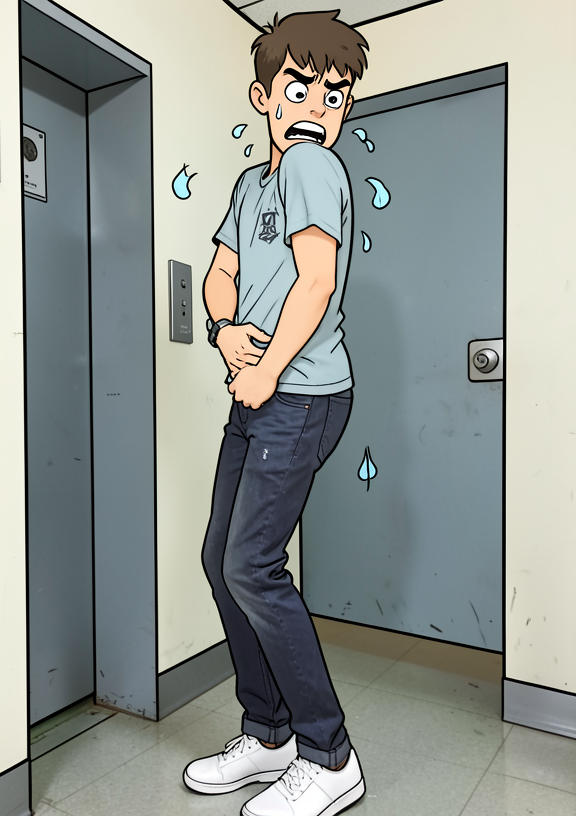

In [234]:
# [STEP 8-2] 생성된 이미지 보기

print(f"크기: {result.size[0]} x {result.size[1]}  |  seed: {SEED}  |  자세 엄격도: {POSE_STRICTNESS}")
result

### 결과가 마음에 안 들 때 — 무엇부터 바꿀까

**순서대로 시도하세요.** 바꾼 뒤에는 **해당 STEP 7 셀 → STEP 8-1 → 8-2** 만 다시 실행하면 됩니다.
모델은 이미 올라가 있으니 STEP 6을 다시 할 필요가 없습니다.

| 증상 | 바꿀 것 | 어떻게 |
| --- | --- | --- |
| **자세가 참조와 다르다** | `POSE_STRICTNESS` (7-3) | `"normal"` → `"strict"` |
| **자세는 맞는데 뻣뻣하다** | `POSE_STRICTNESS` (7-3) | `"normal"` → `"loose"` |
| **알록달록한 막대기가 그림에 나온다** | `POSE_STRICTNESS` (7-3) | `"strict"` → `"normal"` → `"loose"` 순으로 **내려** 보세요. 엄격할수록 참조 이미지를 베끼려 합니다 |
| 막대기가 계속 나온다 | `PROMPT` (7-1) | 맨 앞을 `A photograph of ...` 또는 `A painting of ...` 로 시작해 "이건 사진/그림이다"를 먼저 못 박기 |
| 막대기가 그래도 나온다 | `STEPS` (7-3) | `8` 이상으로 올렸다면 `4` 로 되돌리기. 단계가 많을수록 참조에 더 달라붙습니다 |
| **손·얼굴만 이상하다** | `SEED` (7-3) | 아무 다른 숫자로. 3~4번 반복 |
| **프롬프트 내용이 무시된다** | `PROMPT` (7-1) | 중요한 것을 **첫 문장**에 두고, 문장으로 구체적으로 쓰기 |
| **전체적으로 거칠다** | `STEPS` (7-3) | `4` → `8` 로 올리기 |
| **사람이 여러 명 나온다** | `PROMPT` (7-1) | 맨 앞을 `A single person...` 으로 |
| **원치 않는 물건이 나온다** | `PROMPT` (7-1) | 프롬프트에 `There is no <물건> in the scene.` 을 문장으로 추가 |
| **너무 느리다** | `MAX_SIDE` (4-3) | `768` → `512` 로 낮추고 4-3 → 5-2 → 8-1 재실행 |

### 오류가 났을 때

* `RuntimeError: ComfyUI 실행 중 오류` — 메시지에 원인이 들어 있습니다.
  `out of memory` 가 보이면 STEP 6-3의 `EXTRA_ARGS` 를 `["--lowvram"]` 로 바꾸고 6-3을 다시 실행하세요.
* `NameError: name 'flux2_generate' is not defined` — STEP 6-4를 실행하지 않았습니다.
* `ConnectionError` / `TimeoutError` — ComfyUI 서버가 죽었습니다. **STEP 6-3을 다시 실행**하세요.
  로그는 아래 한 줄로 볼 수 있습니다.

  ```python
  print(open("/content/comfyui.log").read()[-3000:])
  ```

---
# STEP 9 — 저장 · 비교 · 다운로드

## 9-1. 파일로 저장

파일 이름은 **사진 번호만** 씁니다.

| STEP 3-1 | 저장되는 이름 |
| --- | --- |
| `PICK = 0` | `output_01.png` |
| `PICK = 1` | `output_02.png` |
| 같은 사진으로 또 만들면 | `output_01-1.png`, `output_01-2.png` ... |

뒤에 `-1`, `-2` 를 붙이는 것은 **먼저 만든 결과를 덮어쓰지 않기 위해서**입니다.

> 이름에 설정값이 안 들어가므로, 이 셀은 **다시 만들 때 필요한 값(seed·자세강도·단계수 등)을
> 화면에 같이 찍어 줍니다.** 마음에 드는 결과가 나오면 그 줄을
> [`prompts.md`](prompts.md) 에 복사해 두세요.

In [220]:
# [STEP 9-1] 결과를 파일로 저장

# 드라이브 -> git 폴더(C) 복사 명령. 드라이브 문자를 직접 적지 않고 찾아냅니다.
# (C: 는 복사 대상이므로 후보에서 뺍니다.)
COPY_TO_C = r"""
    $src = Get-PSDrive -PSProvider FileSystem | Where-Object { $_.Name -ne 'C' } |
           ForEach-Object { Join-Path $_.Root 'Aiffel_Work\pose-image-tool\samples' } |
           Where-Object { Test-Path $_ } | Select-Object -First 1
    Copy-Item "$src\*" 'C:\Aiffel_Work\pose-image-tool\samples\' -Force
"""

# 파일 이름은 사진 번호만 씁니다.  예: output_01.png
#   output_01 = STEP 3-1에서 PICK = 0 으로 고른 사진
# 같은 이름이 이미 있으면 뒤에 -1, -2 ... 를 붙여 기존 파일을 덮어쓰지 않습니다.

# 저장 설정은 원래 STEP 7-4에서 만들어집니다.
# 7-4를 아직 안 돌렸거나 노트북을 고친 뒤라면, 여기서 알아서 만들고 그대로 진행합니다.
# (멈추지 않습니다. 7-4로 돌아갔다 올 필요 없습니다.)
if "photo_tag" not in globals() or "OUT_DIR" not in globals():
    if "PROJECT_DIR" in globals() and os.path.isdir(PROJECT_DIR):
        OUT_DIR = os.path.join(PROJECT_DIR, "samples")
    else:
        OUT_DIR = "samples"
    os.makedirs(OUT_DIR, exist_ok=True)

    def photo_tag():
        """파일 이름에 쓸 사진 번호. STEP 3-1의 PICK 을 따라갑니다."""
        idx = globals().get("PICK_INDEX")
        return f"output_{idx + 1:02d}" if isinstance(idx, int) else "output"

    print(f"[자동 준비] STEP 7-4가 아직 반영되지 않아 저장 설정을 여기서 만들었습니다.")
    print(f"           저장 폴더   : {OUT_DIR}")
    print(f"           파일 이름   : {photo_tag()}.png")
    print()

BASE_NAME = photo_tag()

OUT_PATH = os.path.join(OUT_DIR, f"{BASE_NAME}.png")
dup = 0
while os.path.exists(OUT_PATH):
    dup += 1
    OUT_PATH = os.path.join(OUT_DIR, f"{BASE_NAME}-{dup}.png")

result.save(OUT_PATH)

print(f"저장 완료: {OUT_PATH}")
print(f"           ({os.path.getsize(OUT_PATH) / 1024:.0f} KB)")
if dup:
    print(f"           같은 이름이 이미 있어 -{dup} 을 붙였습니다.")

# 파일 이름에 설정이 안 들어가므로, 재현에 필요한 값을 여기에 찍어 둡니다.
# 마음에 드는 결과가 나오면 이 두 줄을 prompts.md 에 복사해 두세요.
print()
print("이 그림을 다시 만들려면 필요한 값 (prompts.md 에 적어 두세요)")
print(f"  {os.path.basename(OUT_PATH)}  |  seed={SEED}  {POSE_STRICTNESS}  "
      f"steps={STEPS}  cfg={GUIDANCE}  {WIDTH}x{HEIGHT}")
print(f"  프롬프트: {PROMPT}")

# 구글 드라이브에 저장됐다면, git 폴더(C)로 가져오는 방법을 알려 줍니다.
if OUT_DIR.startswith("/content/drive"):
    print()
    print("저장 위치 안내 — 이 파일은 구글 드라이브에 있습니다.")
    print("  내 PC의 구글 드라이브 폴더에 잠시 뒤 나타납니다.")
    print("  git 폴더(C)로 옮기려면 PowerShell에 아래를 통째로 붙여넣으세요.")
    print("  (드라이브 문자가 G든 X든 알아서 찾습니다)")
    print(COPY_TO_C)

print()
files_now = sorted(os.listdir(OUT_DIR))
print(f"{OUT_DIR} 에 쌓인 파일 {len(files_now)}개 (최근 8개):")
for name in files_now[-8:]:
    print(f"  {name}")

저장 완료: /content/drive/MyDrive/Aiffel_Work/pose-image-tool/outputs/output_02.png
           (426 KB)

이 그림을 다시 만들려면 필요한 값 (prompts.md 에 적어 두세요)
  output_02.png  |  seed=12343  strict  steps=7  cfg=1.0  576x816
  프롬프트: An athlete jumping over the moon,moon in the bottom half of the image, Belly facing up, dramatic pose. dreamy lighting, dusky, ethereal, magical, bright moonlight. Fantasy concept art style, highly detailed.

저장 위치 안내 — 이 파일은 구글 드라이브에 있습니다.
  내 PC의 G 드라이브 동기화 폴더에 잠시 뒤 나타납니다.
  git 폴더(C)로 옮기려면 PowerShell에서 아래 한 줄을 실행하세요.
    Copy-Item "G:\내 드라이브\Aiffel_Work\pose-image-tool\outputs\*" "C:\Aiffel_Work\pose-image-tool\outputs\" -Force

/content/drive/MyDrive/Aiffel_Work/pose-image-tool/outputs 에 쌓인 파일 2개 (최근 8개):
  output_01.png
  output_02.png


## 9-2. 참조 · 스켈레톤 · 결과 나란히 비교

세 장을 나란히 놓고 보면 **자세가 제대로 옮겨졌는지 한눈에** 판단할 수 있습니다.

* 1번(참조)과 2번(스켈레톤)이 다르다 → **STEP 5 문제**. 사진을 크롭해서 다시 추출하세요.
* 2번(스켈레톤)과 3번(결과)이 다르다 → **STEP 7 문제**. `POSE_STRICTNESS` 를 `"strict"` 로 올리세요.

> FLUX.2 는 자세를 **참고**하는 방식이라, ControlNet을 쓰던 이전 버전만큼 딱 맞지는 않습니다.
> 팔다리 각도가 조금 다른 정도는 정상 범위로 보세요.

아래 코드는 STEP 1-3에서 설치한 한글 폰트를 찾아 그래프에 등록합니다.
폰트를 못 찾으면 자동으로 영어 제목으로 바뀝니다.

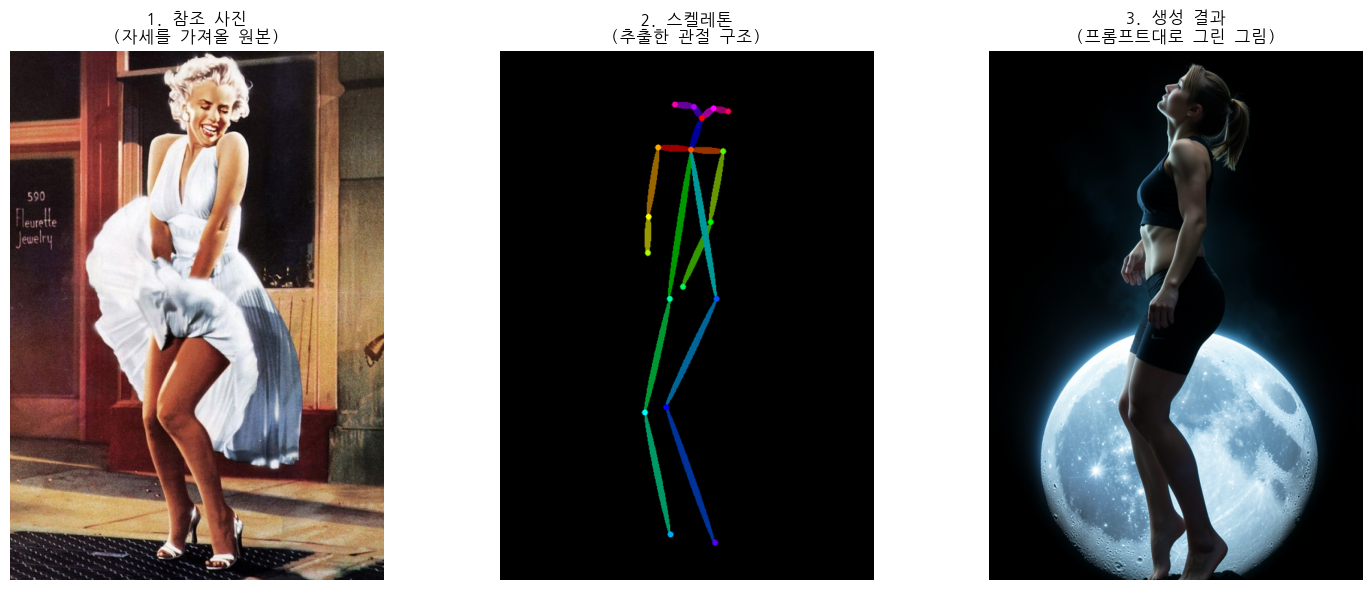

In [221]:
# [STEP 9-2] 세 장 나란히 비교

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# STEP 1-3에서 설치한 나눔고딕을 찾아 등록합니다. (없으면 영어 제목으로 자동 전환)
KOREAN_FONT = None
for path in fm.findSystemFonts():
    if "Nanum" in path and path.endswith((".ttf", ".otf")):
        fm.fontManager.addfont(path)
        KOREAN_FONT = fm.FontProperties(fname=path).get_name()
        break

if KOREAN_FONT:
    plt.rcParams["font.family"] = KOREAN_FONT
    plt.rcParams["axes.unicode_minus"] = False
    titles = ["1. 참조 사진\n(자세를 가져올 원본)",
              "2. 스켈레톤\n(추출한 관절 구조)",
              "3. 생성 결과\n(프롬프트대로 그린 그림)"]
else:
    titles = ["1. Reference\n(source photo)",
              "2. Skeleton\n(extracted pose)",
              "3. Result\n(generated)"]
    print("한글 폰트를 찾지 못해 영어 제목으로 표시합니다. (STEP 1-2 참고)")

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
for ax, img, title in zip(axes, [pose_src, pose_map, result], titles):
    ax.imshow(img)
    ax.set_title(title, fontsize=12)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 9-3. *(선택)* 내 컴퓨터로 내려받기

**3-1로 드라이브를 연결했다면 이 셀은 실행하지 않아도 됩니다.**
결과가 이미 프로젝트 폴더의 `samples/` 안에 저장되어 있고, 구글 드라이브가 **내 PC로 자동 동기화**합니다.
잠시 뒤 탐색기에서 프로젝트 폴더의 `samples` 를 열어 보세요.

드라이브를 연결하지 않고 3-2(URL)로 진행했다면 결과가 **임시 서버에만** 있습니다.
런타임이 끊기면 사라지므로 이 셀로 내려받으세요.

In [222]:
# [STEP 9-3] 결과 이미지 내려받기

if IN_COLAB:
    from google.colab import files

    print("브라우저 다운로드가 시작됩니다. (팝업이 차단되면 허용해 주세요)")
    files.download(OUT_PATH)
else:
    print(f"로컬 환경입니다. 파일 위치: {os.path.abspath(OUT_PATH)}")

브라우저 다운로드가 시작됩니다. (팝업이 차단되면 허용해 주세요)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 9-4. 설정을 바꿔 가며 실험하는 법 — VS Code 사용법

한 번 전체 실행을 끝냈다면, 이제 **STEP 7-3 → 8-1 → 9-1 세 칸만** 반복하면 됩니다.
모델과 ComfyUI 서버는 그대로 살아 있으므로 앞 단계를 다시 할 필요가 없습니다.

### 셀 실행 단축키

| 단축키 | 동작 | 언제 |
| --- | --- | --- |
| **`Ctrl` + `Enter`** | **이 셀만 실행하고 제자리에 머무름** | 실험 반복에 이걸 쓰세요 |
| `Shift` + `Enter` | 실행하고 아래 셀로 이동 | 처음 쭉 훑을 때 |
| — | 셀 왼쪽 **▶** 버튼 클릭 | 단축키 대신 |

셀 안의 코드를 고치려면 **회색 코드 영역을 클릭**하면 커서가 생깁니다. 고친 뒤 `Ctrl`+`Enter`.

### 반복 순서

```
  1. STEP 7-3 셀에서 값을 고친다  (예: SEED = 12345 -> 777)
  2. STEP 7-3 에서 Ctrl+Enter    <- 바꾼 값을 반영
  3. STEP 8-1 에서 Ctrl+Enter    <- 생성 (30~90초)
  4. STEP 8-2 에서 Ctrl+Enter    <- 결과 보기
  5. STEP 9-1 에서 Ctrl+Enter    <- 저장 (파일명에 설정값이 들어감)
```

**다시 실행하지 않아도 되는 것**: STEP 0~6 (설치·모델·엔진), STEP 7-4 (저장 폴더 설정).

> 노트북 파일이 바뀌어 7-4가 반영되지 않은 상태라도, 9-1과 10-2가 **알아서 준비하고 진행**합니다.
> 그때는 `[자동 준비]` 로 시작하는 줄이 한 번 찍힙니다. 오류가 아니니 그냥 두셔도 됩니다.

> **주의**: 7-3의 값을 고치기만 하고 **7-3 셀을 실행하지 않으면** 바뀐 값이 반영되지 않습니다.
> 파이썬은 셀을 실행하는 순간에만 변수를 갱신합니다. 고쳤으면 반드시 그 셀부터 실행하세요.

### 무엇부터 실험할까

| 실험 | 고칠 값 | 방법 |
| --- | --- | --- |
| **마음에 드는 그림 찾기** | `SEED` (7-3) | 아무 숫자로 4~5번 바꿔 보고 고르기 |
| **자세 강도 조절** | `POSE_STRICTNESS` (7-3) | `"loose"` / `"normal"` / `"strict"` 세 번 돌려 비교 |
| **세부 묘사 높이기** | `STEPS` (7-3) | `4` / `8` 비교 |
| **다른 장면** | `PROMPT` (7-1) | 7-1을 고치면 **7-1도 실행**해야 반영됩니다 |

`SEED`를 고정하고 다른 값 하나만 바꾸면 **그 값의 효과만** 순수하게 볼 수 있습니다.

저장 파일 이름은 **`output_01.png`** 처럼 사진 번호만 씁니다.
같은 사진으로 여러 번 만들면 `output_01-1.png`, `output_01-2.png` 로 쌓입니다.

이름만으로는 어떤 설정이었는지 알 수 없으므로, **9-1이 저장할 때마다 그 값을 화면에 찍어 줍니다.**
마음에 드는 것이 나오면 그 줄을 [`prompts.md`](prompts.md) 에 복사해 두세요. 이런 모양입니다.

```
이 그림을 다시 만들려면 필요한 값 (prompts.md 에 적어 두세요)
  output_01.png  |  seed=777  strict  steps=4  cfg=1.0  576x768
  프롬프트: A knight in ornate silver armor ...
```

### 여러 장을 한 번에 돌리고 싶다면

위 과정을 손으로 반복하는 대신 **STEP 10**을 쓰세요. 목록에 적어 둔 만큼 자동으로 연속 생성합니다.

---
# STEP 10 — 같은 자세로 여러 장 한 번에 뽑기 *(선택)*

**같은 스켈레톤**을 쓰면서 프롬프트와 seed만 바꿔 여러 장을 연속으로 만듭니다.
모델은 이미 메모리에 있으므로 **한 장당 30~90초씩만** 더 걸립니다.

## 이럴 때 씁니다

1. **같은 포즈로 캐릭터만 바꿔 보기** — 기사 / 댄서 / 우주비행사 …
2. **프롬프트는 고정하고 seed만 바꿔** 손·얼굴이 잘 나온 것 고르기
3. **설정 비교** — 프롬프트와 seed를 고정하고 `POSE_STRICTNESS` 만 바꿔 효과 확인

> **시간 계산을 먼저 하세요.** 3장이면 2~5분, 10장이면 10분 넘게 걸립니다.
> Colab 무료 GPU는 오래 붙잡고 있으면 사용량 한도에 걸립니다.

## 10-1. 만들 목록 정하기

`VARIANTS` 에 `("프롬프트", seed)` 형태로 원하는 만큼 줄을 추가하세요.

In [223]:
# [STEP 10-1] 만들 목록 정하기

# ("프롬프트", seed) 형태로 원하는 만큼 줄을 추가하세요. 프롬프트는 영어 문장으로.
VARIANTS = [
    ("A single knight in ornate silver armor on a misty battlefield at dawn. "
     "Fantasy concept art style.", 12345),
    ("A single street dancer in an oversized hoodie on a neon-lit city street at night. "
     "Cinematic photograph, shallow depth of field.", 999),
    ("A single astronaut in a white spacesuit on the surface of Mars, red dust in the air. "
     "Science fiction illustration.", 2024),
]

# 참고: 같은 프롬프트로 seed만 바꿔 고르고 싶다면 아래처럼 쓰면 됩니다.
# VARIANTS = [(PROMPT, s) for s in [1, 2, 3, 4]]

print(f"총 {len(VARIANTS)}장을 만듭니다. 예상 소요 시간: 약 {len(VARIANTS)}~{len(VARIANTS) * 2}분\n")
for i, (p, s) in enumerate(VARIANTS, start=1):
    print(f"  {i}. seed={s:<8} {p[:60]}...")

총 3장을 만듭니다. 예상 소요 시간: 약 3~6분

  1. seed=12345    A single knight in ornate silver armor on a misty battlefiel...
  2. seed=999      A single street dancer in an oversized hoodie on a neon-lit ...
  3. seed=2024     A single astronaut in a white spacesuit on the surface of Ma...


## 10-2. 연속 생성

[1/3] seed=12345 | A single knight in ornate silver armor on a misty battl...
        완료 (22초) -> output_02-1.png
[2/3] seed=999 | A single street dancer in an oversized hoodie on a neon...
        완료 (22초) -> output_02-2.png
[3/3] seed=2024 | A single astronaut in a white spacesuit on the surface ...
        완료 (22초) -> output_02-3.png

3장 저장 완료 (총 67초) -> /content/drive/MyDrive/Aiffel_Work/pose-image-tool/outputs/ 폴더


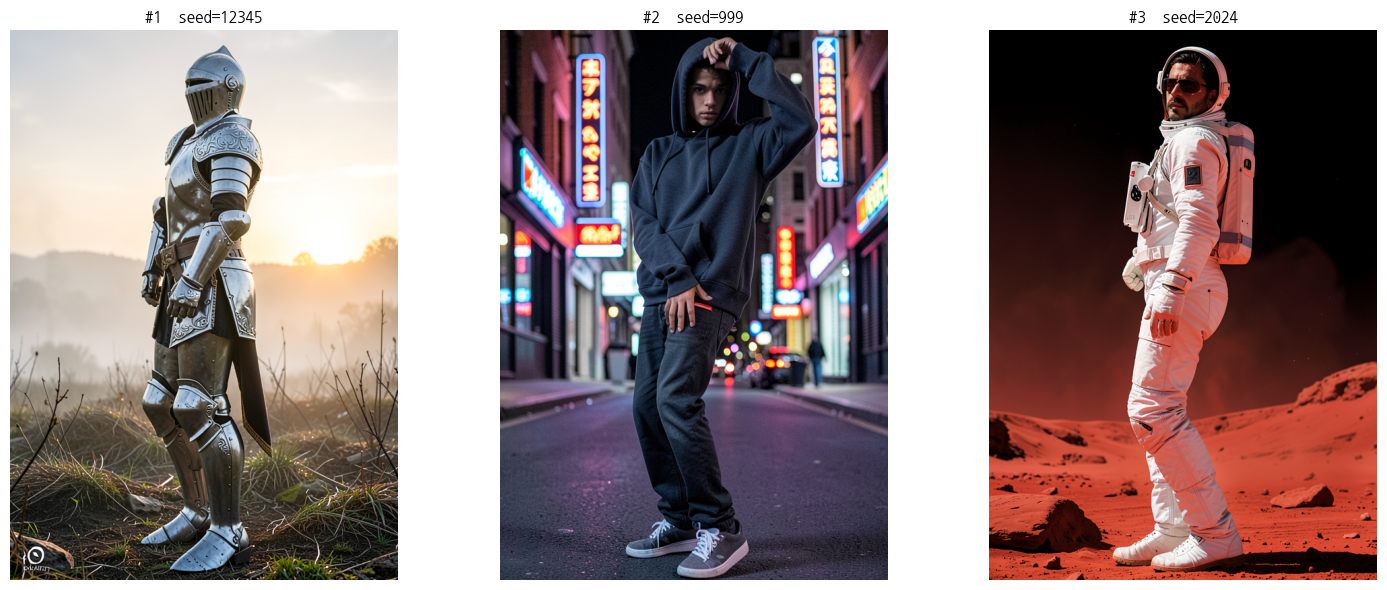

In [224]:
# [STEP 10-2] 연속 생성

# 저장 설정은 원래 STEP 7-4에서 만들어집니다.
# 7-4를 아직 안 돌렸거나 노트북을 고친 뒤라면, 여기서 알아서 만들고 그대로 진행합니다.
# (멈추지 않습니다. 7-4로 돌아갔다 올 필요 없습니다.)
if "photo_tag" not in globals() or "OUT_DIR" not in globals():
    if "PROJECT_DIR" in globals() and os.path.isdir(PROJECT_DIR):
        OUT_DIR = os.path.join(PROJECT_DIR, "samples")
    else:
        OUT_DIR = "samples"
    os.makedirs(OUT_DIR, exist_ok=True)

    def photo_tag():
        """파일 이름 앞에 붙일 사진 번호. STEP 3-1의 PICK 을 따라갑니다."""
        idx = globals().get("PICK_INDEX")
        return f"output_{idx + 1:02d}" if isinstance(idx, int) else "output"

    print(f"[자동 준비] STEP 7-4가 아직 반영되지 않아 저장 설정을 여기서 만들었습니다.")
    print(f"           저장 폴더   : {OUT_DIR}")
    print(f"           이름 앞부분 : {photo_tag()}")
    print()

results = []
t_all = time.time()

for i, (prompt, seed) in enumerate(VARIANTS, start=1):
    print(f"[{i}/{len(VARIANTS)}] seed={seed} | {prompt[:55]}...")

    img, sec = flux2_generate(
        prompt=prompt,
        skeleton=pose_map,
        width=WIDTH,
        height=HEIGHT,
        steps=STEPS,
        cfg=GUIDANCE,
        seed=seed,
        negative=NEGATIVE_PROMPT,
        strictness=POSE_STRICTNESS,
        quiet=True,
    )

    # 이름은 output_0# 형식만 씁니다. 같은 이름이 있으면 -1, -2 ... 가 붙습니다.
    path = os.path.join(OUT_DIR, f"{photo_tag()}.png")
    n = 0
    while os.path.exists(path):
        n += 1
        path = os.path.join(OUT_DIR, f"{photo_tag()}-{n}.png")
    img.save(path)
    results.append((img, f"#{i}  seed={seed}"))
    print(f"        완료 ({sec:.0f}초) -> {os.path.basename(path)}")

print(f"\n{len(results)}장 저장 완료 (총 {time.time() - t_all:.0f}초) -> {OUT_DIR}/ 폴더")

# 만든 그림을 한 줄로 늘어놓고 봅니다. (STEP 9-2를 먼저 실행해야 plt 가 준비됩니다)
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 6))
if len(results) == 1:
    axes = [axes]
for ax, (img, title) in zip(axes, results):
    ax.imshow(img)
    ax.set_title(title, fontsize=12)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 10-3. 결과 전부 zip으로 묶어 내려받기

In [225]:
# [STEP 10-3] 결과 이미지만 zip으로 묶어 내려받기

import zipfile

# samples/ 에는 참조 사진도 함께 있으므로, output_ 으로 시작하는 결과물만 담습니다.
targets = sorted(n for n in os.listdir(OUT_DIR)
                 if n.lower().startswith("output_") and n.lower().endswith(".png"))

zip_path = "pose_tool_outputs.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for n in targets:
        z.write(os.path.join(OUT_DIR, n), arcname=n)

print(f"결과 {len(targets)}개를 {zip_path} 로 묶었습니다. ({os.path.getsize(zip_path) / 1024:.0f} KB)")

if IN_COLAB:
    from google.colab import files

    files.download(zip_path)
    print("다운로드가 시작됩니다.")
else:
    print(f"로컬 환경입니다. 위치: {os.path.abspath(zip_path)}")

5개 파일을 /content/pose_tool_outputs.zip 로 묶었습니다. (3007 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

다운로드가 시작됩니다.


---
# 부록 A — 문제 해결

## A-1. 오류 메시지가 뜰 때

| 오류 메시지 | 원인 | 해결 방법 |
| --- | --- | --- |
| `nvidia-smi: command not found` | GPU가 꺼져 있음 | STEP 0-1 — 런타임 유형을 T4 GPU로 |
| `ERROR: pip's dependency resolver ... gradio ... huggingface-hub ... incompatible` | **정상 동작**. 안 쓰는 gradio와의 버전 충돌 경고 | 무시. 1-4 셀 결과만 확인 |
| `ModuleNotFoundError: No module named 'controlnet_aux'` | 설치 셀을 안 돌림 | STEP 1-2 실행 |
| `RuntimeError: POSE_IMAGE가 없습니다` | STEP 3을 건너뜀 | STEP 3-1 또는 3-2 실행 |
| `FileNotFoundError` | 경로 오타 또는 드라이브 미연결 | STEP 3-1 다시 실행 |
| **3-3 셀이 끝나지 않고 계속 `[*]`** | VS Code에서 `files.upload()` 는 동작하지 않음 | 정지 버튼으로 중단 후 **3-1** 또는 **3-2** 사용 |
| **`drive.mount()` 에서 멈춤** | VS Code에서 구글 인증창이 뜨지 않음 | 정지 버튼으로 중단 후 **3-2 (URL)** 사용 |
| `RuntimeError: OpenPose 모델이 메모리에 없습니다` | STEP 6-3이 메모리 확보를 위해 내림 | **STEP 5-1** 실행 후 5-2 다시 실행 |
| `NameError: name 'pose_map' is not defined` | STEP 5를 건너뜀 | STEP 5-1 → 5-2 → 5-3 실행 |
| `NameError: name 'flux2_generate' is not defined` | STEP 6-4를 건너뜀 | STEP 6-4 실행 |
| 출력에 `[자동 준비]` 로 시작하는 줄 | STEP 7-4가 아직 반영되지 않음 | **오류 아님.** 9-1이 알아서 준비하고 진행한 것 |
| **`ComfyUI 서버가 뜨지 않았습니다`** | 라이브러리 설치 실패 또는 메모리 부족 | 출력된 로그를 읽고, 대부분 STEP 1-1 재실행으로 해결 |
| **`없는 부품: ['UnetLoaderGGUF']`** | GGUF 부품이 안 깔림 | STEP 1-1 → 6-3 순서로 다시 실행 |
| `ConnectionError` / `TimeoutError` (STEP 8) | ComfyUI 서버가 죽음 | **STEP 6-3** 다시 실행. 로그는 아래 참고 |
| `ComfyUI 실행 중 오류 ... out of memory` | GPU 메모리 부족 | ① 6-3의 `EXTRA_ARGS = ["--lowvram"]` ② 4-3의 `MAX_SIDE=512` |
| `wget: unable to resolve host` (STEP 6-2) | 인터넷 문제 | STEP 6-2 다시 실행 (이어받습니다) |
| 그래프 제목이 `□□□` | 한글 폰트 없음 | STEP 1-3 실행 후 9-2 다시 실행 |

**ComfyUI 로그 보는 법** — 새 코드 셀을 하나 만들어 아래를 붙여 넣고 실행하세요.

```python
print(open("/content/comfyui.log").read()[-3000:])
```

## A-2. 오류는 없는데 결과가 이상할 때

| 증상 | 원인 | 해결 방법 |
| --- | --- | --- |
| 자세가 참조와 많이 다르다 | 지시가 약함 | `POSE_STRICTNESS` → `"strict"` |
| 자세는 맞는데 뻣뻣하다 | 지시가 과함 | `POSE_STRICTNESS` → `"loose"` |
| **알록달록한 막대기가 그림에 그대로 나온다** | 모델이 참조 도면을 그려야 할 대상으로 오해 | ① `POSE_STRICTNESS` 를 `"normal"` → `"loose"` 로 **내리기** ② 프롬프트 맨 앞을 `A photograph of ...` 로 시작 ③ `STEPS` 를 `4` 로 되돌리기 |
| 스켈레톤이 완전히 검은색 | 인물 인식 실패 | STEP 4-2에서 인물 주변만 크롭 |
| 손가락이 뭉개진다 | 운의 영역 | `SEED` 바꿔 여러 장(STEP 10). FLUX.2는 이전 버전보다 훨씬 낫습니다 |
| 얼굴이 무너진다 | 얼굴 영역이 너무 작음 | 상반신 위주 참조 사진 / `MAX_SIDE=1024` |
| 프롬프트 내용이 무시된다 | 문장이 모호함 | 중요한 것을 **첫 문장**에, 구체적인 명사로 |
| 사람이 여러 명 나온다 | 프롬프트 | 맨 앞을 `A single person...` 으로 |
| 한 장에 3분 넘게 걸린다 | 해상도가 큼 | `MAX_SIDE` 를 `512` 로 낮추기 |

## A-3. 자주 묻는 질문

**Q. 런타임이 끊겼습니다. 처음부터 다 해야 하나요?**
네. 그리고 이번 버전은 **모델 11GB를 다시 받아야 해서 20분쯤 걸립니다.**
Colab은 일정 시간 조작이 없으면 연결을 끊고 설치 내용과 파일을 모두 지웁니다.
그래서 한 번 연결했을 때 **실험을 몰아서 하는 편**이 좋습니다.

**Q. 11GB를 매번 안 받을 수는 없나요?**
구글 드라이브에 모델을 복사해 두면 이론상 가능하지만, 무료 드라이브 용량(15GB)을 거의 다 씁니다.
또 드라이브에서 읽는 속도가 느려서 체감 이득이 크지 않습니다. 권장하지 않습니다.

**Q. 왜 ControlNet을 안 쓰나요?**
FLUX.2 klein 용 OpenPose ControlNet이 (2026년 9월 기준) 아직 공개되지 않았습니다.
자세 정확도가 최우선이라면 `main` 브랜치(SD 1.5 + ControlNet)를 쓰세요.

**Q. 무료 GPU 사용 시간에 제한이 있나요?**
있습니다. 하루 몇 시간 정도 쓰면 "사용량 한도 초과" 안내가 나오고 몇 시간 뒤 풀립니다.
이번 버전은 모델이 커서 이전보다 한도에 빨리 닿습니다.

**Q. 한국어 프롬프트를 쓰면 안 되나요?**
FLUX.2의 텍스트 인코더(Qwen3)는 한국어도 조금 알아듣지만, 품질이 확연히 떨어집니다. 영어로 쓰세요.

**Q. 참조 사진 속 사람의 얼굴이 결과에 나오나요?**
아니요. 모델에 넘기는 것은 **스켈레톤 그림뿐**이고 원본 사진은 넘기지 않습니다.
얼굴·피부색·옷 등 외모 정보는 전혀 전달되지 않습니다.

**Q. 같은 결과를 나중에 다시 만들려면 무엇을 적어 둬야 하나요?**
`UNET_NAME`, `PROMPT`, `WIDTH`/`HEIGHT`, `STEPS`, `GUIDANCE`, `POSE_STRICTNESS`, `SEED`,
그리고 **참조 사진 파일** 입니다. 이 전부가 같으면 똑같은 그림이 나옵니다.

---

# 부록 B — 용어 사전

| 용어 | 뜻 |
| --- | --- |
| **FLUX.2 [klein]** | Black Forest Labs가 만든 이미지 생성 모델. 이 노트북은 4B(40억 파라미터) 판을 씁니다. |
| **distilled (증류)** | 큰 모델의 실력을 작은 모델에 속성으로 옮긴 것. 적은 단계로 그리는 대신 네거티브 프롬프트를 못 씁니다. |
| **양자화 / GGUF** | 모델 속 숫자의 정밀도를 낮춰 파일을 줄이는 기술과 그 파일 형식. 16GB → 2.6GB. |
| **ComfyUI** | 부품(노드)을 선으로 이어 이미지를 만드는 생성 엔진. 이 노트북은 화면 없이 API로만 씁니다. |
| **노드(node)** | ComfyUI의 부품 하나. "모델 불러오기", "프롬프트 인코딩" 처럼 한 가지 일만 합니다. |
| **워크플로우** | 노드를 어떻게 이을지 적은 설계도. STEP 6-4의 `_build_workflow()` 가 만듭니다. |
| **참조 이미지 (image reference)** | 모델이 그리는 내내 보고 있는 그림. 여기서는 스켈레톤이 그 역할을 합니다. |
| **`ReferenceLatent`** | 참조 이미지를 프롬프트에 매달아 주는 ComfyUI 부품. 이 노트북의 핵심. |
| **OpenPose** | 사진에서 사람의 관절 위치를 찾아내는 모델. |
| **스켈레톤** | 관절을 점과 선으로 그린 검은 배경 이미지. |
| **텍스트 인코더** | 프롬프트를 모델이 이해하는 숫자로 바꾸는 부품. FLUX.2는 Qwen3-4B를 씁니다. |
| **프롬프트** | 무엇을 그릴지 적는 글. 영어 문장으로 씁니다. |
| **네거티브 프롬프트** | 그리지 말아야 할 것을 적는 글. `GUIDANCE > 1.0` 일 때만 작동합니다. |
| **seed** | 무작위 생성의 출발점 번호. 같으면 같은 결과가 나옵니다. |
| **steps** | 노이즈를 걷어내는 반복 횟수. klein 4B는 4면 충분합니다. |
| **guidance scale (CFG)** | 프롬프트를 얼마나 강하게 따를지의 배율. 여기서는 1.0이 기본. |
| **latent (잠재 공간)** | 이미지를 1/16 크기로 압축한 내부 표현. 계산은 여기서 이루어집니다. |
| **VAE** | latent를 실제 픽셀 이미지로 펼쳐 주는 부품. |
| **fp16 / float16** | 숫자를 16비트로 저장하는 방식. 메모리 절반, 속도 2배. |
| **OOM** | Out Of Memory. 메모리 부족 오류. |
| **CUDA** | NVIDIA GPU에서 계산을 돌리기 위한 규격의 이름. |

---

# 부록 C — 다음에 해 볼 것

* **실험 기록 남기기** — 좋은 결과가 나오면 프롬프트와 설정을 [`prompts.md`](prompts.md) 에 적어 두세요.
  나중에 재현하려면 `SEED` 와 `POSE_STRICTNESS` 까지 필요합니다.
* **표정까지 따라 하기** — STEP 5-2에서 `include_face=True` 로 바꾸면
  참조 사진의 얼굴 방향과 표정까지 스켈레톤에 들어갑니다.
* **손 모양까지 따라 하기** — STEP 5-2에서 `include_hand=True`.
  단, 원본에서 손이 선명하게 보일 때만 효과가 있습니다.
* **fp8 원본 써 보기** — STEP 6-1의 `USE_GGUF` 를 `False` 로. 품질이 조금 올라갑니다.
* **자세 정확도가 더 필요하다면** — `main` 브랜치(SD 1.5 + ControlNet)로 돌아가세요.
  ControlNet은 자세를 매 단계 강제하므로 훨씬 정확합니다. 대신 그림 품질은 떨어집니다.
* **FLUX.2 용 ControlNet이 나오면** — 알리바바가 공개한 `FLUX.2-dev-Fun-Controlnet-Union` 이
  klein 4B 까지 지원하게 되면, 두 방식의 장점을 합칠 수 있습니다.